# BIRD Mini-Dev 500: Four-Way Base/SFT × Evidence Evaluation

This notebook fairly compares four conditions on the **same 500 examples from the official BIRD Mini-Dev SQLite dataset**:

1. Base model without BIRD evidence
2. Base model with BIRD evidence
3. SFT model without BIRD evidence
4. SFT model with BIRD evidence

The primary metric is **Execution Accuracy (EX)** as defined by BIRD. Auxiliary metrics include Valid SQL Rate, Normalized Exact Match, generation time, and input/output token counts, with results also broken down by difficulty and database.

The notebook also includes:

- Automatic download of the official dataset and SQLite databases
- Dataset revision pinning and integrity checks (500 examples and 11 databases)
- A controlled 2 × 2 ablation: model (`Base`/`SFT`) × evidence (`No`/`Yes`)
- Identical schema, prompt structure, decoding parameters, and 4-bit loading settings
- Resume support and run-configuration fingerprint checks
- Per-example CSV outputs, summary JSON files, official prediction files, comparison CSVs, and charts
- Four-way per-example outputs, paired effects, confidence intervals, and interaction analysis

> Estimated runtime: the four conditions require 2,000 generations. Based on your earlier speeds, generation alone is about 131 minutes; allow roughly 2.5–3 hours on an A100. Each model is loaded only once and its two evidence conditions are run back-to-back.

Before running: in Colab, select **Runtime → Change runtime type → GPU (A100 recommended)**.


## 0. Evaluation Protocol

- Use the classic **BIRD Mini-Dev 500**, not the later Mini-Dev V2 with 780 examples.
- Load the `mini_dev_sqlite` split from the official Hugging Face dataset: `birdsql/bird_mini_dev`.
- Pin the dataset revision to `f65faf4ae3b638c1fa6df1d3370c8d92c8366301` so future dataset updates do not affect reproducibility.
- Use the complete official BIRD SQLite database package, `minidev_0703.zip`.
- Match the official EX implementation: execute the predicted SQL and Gold SQL separately, convert the returned rows to sets, and compare the sets for equality. Row order and duplicate-row counts therefore do not affect the comparison.
- Mini-Dev 500 is a public development set. It is suitable as a new, checkpoint-independent evaluation set for this project, but it is not a hidden test set in the strict sense.

Official resources:

- [BIRD Mini-Dev GitHub](https://github.com/bird-bench/mini_dev)
- [BIRD Mini-Dev Hugging Face](https://huggingface.co/datasets/birdsql/bird_mini_dev)
- [Official EX evaluator](https://github.com/bird-bench/mini_dev/blob/main/evaluation/evaluation_ex.py)


## 1. Install Dependencies


In [1]:
!pip -q install -U \
    "transformers>=4.48" \
    "peft>=0.14" \
    "accelerate>=1.2" \
    "bitsandbytes>=0.45" \
    "datasets>=3.2" \
    "gdown>=5.2" \
    "sqlglot>=26.0" \
    "scipy>=1.11" \
    pandas matplotlib seaborn tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 145.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.8/741.8 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 139.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 157.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Imports, Random Seeds, and Google Drive


In [2]:
import gc
import hashlib
import json
import math
import os
import random
import re
import shutil
import sqlite3
import statistics
import time
import warnings
import zipfile
from pathlib import Path
from urllib.parse import quote

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlglot
import torch
from datasets import load_dataset
from IPython.display import display
from peft import PeftConfig, PeftModel
from scipy.stats import binomtest
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    set_seed,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("No GPU was detected. In Colab, select Runtime → Change runtime type → GPU.")

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)
print("BF16 supported:", torch.cuda.is_bf16_supported())

from google.colab import drive
drive.mount("/content/drive")


GPU: NVIDIA A100-SXM4-40GB
CUDA: 12.8
BF16 supported: True
Mounted at /content/drive


## 3. Configuration

The paths below already match this project's Google Drive layout, so no path changes are required as long as the project root remains `/content/drive/MyDrive/bird-text2sql-sft`.

- Raw Mini-Dev data and the Hugging Face cache are stored under `data/`.
- The fixed 500-example snapshot is stored under `processed/`.
- Evaluation outputs are stored under `results/minidev500_four_way/`.
- The SFT adapter is loaded from `training/qwen2.5-coder-7b-bf16-lora-sft/final_adapter/`.
- The expected notebook location is `notebooks/BIRD_MiniDev500_Four_Way.ipynb`.

To evaluate a specific checkpoint instead of `final_adapter`, change only `SFT_ADAPTER_DIR` to a directory such as `CHECKPOINTS_DIR / "checkpoint-400"` or `CHECKPOINTS_DIR / "checkpoint-1200"`.


In [3]:
# ========================= PROJECT LAYOUT =========================
PROJECT_ROOT = Path("/content/drive/MyDrive/bird-text2sql-sft")

DATA_DIR = PROJECT_ROOT / "data"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
PROCESSED_DIR = PROJECT_ROOT / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

TRAINING_RUN_DIR = (
    PROJECT_ROOT
    / "training"
    / "qwen2.5-coder-7b-bf16-lora-sft-v2-filtered-mixed-evidence-lr2e-5-len8192"
)
CHECKPOINTS_DIR = TRAINING_RUN_DIR / "checkpoints"
SFT_ADAPTER_DIR = TRAINING_RUN_DIR / "final_adapter"
TRAINING_LOGS_DIR = TRAINING_RUN_DIR / "logs"

# Keep this evaluation in its own subdirectory under results/.
PROJECT_DIR = RESULTS_DIR / "minidev500_four_way"

for directory in [
    DATA_DIR,
    NOTEBOOKS_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    PROJECT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)
# ==================================================================

BASE_MODEL_ID = "Qwen/Qwen2.5-Coder-7B-Instruct"

# Official dataset revision and database package
HF_DATASET_ID = "birdsql/bird_mini_dev"
HF_REVISION = "f65faf4ae3b638c1fa6df1d3370c8d92c8366301"
HF_SPLIT = "mini_dev_sqlite"
OFFICIAL_DB_GOOGLE_DRIVE_ID = "13VLWIwpw5E3d5DUkMvzw7hvHE67a4XkG"

# Persist all downloaded BIRD data and Hugging Face files under data/.
LOCAL_DATA_ROOT = DATA_DIR / "bird_minidev500"
LOCAL_ZIP_PATH = LOCAL_DATA_ROOT / "minidev_0703.zip"
LOCAL_EXTRACT_DIR = LOCAL_DATA_ROOT / "extracted"
HF_CACHE_DIR = DATA_DIR / "hf_cache"

# Fair inference settings: both models must use identical values
LOAD_IN_4BIT = False
MAX_INPUT_TOKENS = 8192
MAX_NEW_TOKENS = 256
DO_SAMPLE = False
TEMPERATURE = None       # Do not pass temperature when do_sample=False
TOP_P = None             # Do not pass top_p when do_sample=False
SQL_TIMEOUT_SECONDS = 30.0

# Experiment controls
RUN_BASELINE = True
RUN_SFT = True
RESUME = True             # Continue from an existing CSV after a Colab interruption
FORCE_RESTART = True     # True deletes old CSV/config files for the current label and reruns it
SAVE_EVERY = 5
DEBUG_LIMIT = None        # Must be None for the full run; temporarily set to 5 for debugging

# Controlled evidence ablation. Both conditions keep the same prompt structure;
# the no-evidence condition substitutes only the evidence contents with `None`.
PROMPT_VERSION = "bird_schema_evidence_ablation_chat_v2"
EVIDENCE_CONDITIONS = [False, True]

EXPERIMENTS = {
    "baseline_no_evidence": {"model_type": "baseline", "use_evidence": False},
    "baseline_with_evidence": {"model_type": "baseline", "use_evidence": True},
    "sft_no_evidence": {"model_type": "sft", "use_evidence": False},
    "sft_with_evidence": {"model_type": "sft", "use_evidence": True},
}

print("Project root:", PROJECT_ROOT)
print("SFT adapter directory:", SFT_ADAPTER_DIR)
print("Evaluation results directory:", PROJECT_DIR)


Project root: /content/drive/MyDrive/bird-text2sql-sft
SFT adapter directory: /content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-sft-v2-filtered-mixed-evidence-lr2e-5-len8192/final_adapter
Evaluation results directory: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_four_way


### 3.1 Verify the Project Layout and Adapter Path

The next cell verifies the configured `final_adapter` directory. If it is missing, the notebook searches only inside this training run, including its `checkpoints/` directory, instead of scanning the entire Google Drive.


In [4]:
def find_adapter_candidates(root=TRAINING_RUN_DIR, max_results=30):
    candidates = []
    if not root.exists():
        return candidates

    for config_path in root.rglob("adapter_config.json"):
        folder = config_path.parent
        if (folder / "adapter_model.safetensors").exists() or (folder / "adapter_model.bin").exists():
            candidates.append(folder)
            if len(candidates) >= max_results:
                break
    return candidates


adapter_required = SFT_ADAPTER_DIR / "adapter_config.json"
if RUN_SFT and not adapter_required.exists():
    print("The configured final_adapter directory is invalid:", SFT_ADAPTER_DIR)
    print("\nCandidate adapter directories found in the configured training run:")
    candidates = find_adapter_candidates()
    if candidates:
        for p in candidates:
            print(" -", p)
    else:
        print("(No directory containing adapter_config.json and adapter weights was found.)")
    raise FileNotFoundError(
        "Confirm the project layout or update SFT_ADAPTER_DIR in the previous cell, then rerun this cell."
    )

if RUN_SFT:
    peft_config = PeftConfig.from_pretrained(str(SFT_ADAPTER_DIR))
    print("Adapter:", SFT_ADAPTER_DIR)
    print("Adapter recorded base model:", peft_config.base_model_name_or_path)


Adapter: /content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-sft-v2-filtered-mixed-evidence-lr2e-5-len8192/final_adapter
Adapter recorded base model: Qwen/Qwen2.5-Coder-7B-Instruct


## 4. Download and Pin the Mini-Dev 500 Dataset


In [5]:
dataset_dict = load_dataset(
    HF_DATASET_ID,
    revision=HF_REVISION,
    cache_dir=str(HF_CACHE_DIR),
)

if HF_SPLIT not in dataset_dict:
    raise KeyError(f"Could not find split={HF_SPLIT}; available splits: {list(dataset_dict.keys())}")

raw_split = dataset_dict[HF_SPLIT]
print(raw_split)
print("Columns:", raw_split.column_names)


def first_present(example, names, default=None):
    for name in names:
        if name in example and example[name] is not None:
            return example[name]
    return default


records = []
for position, example in enumerate(raw_split):
    gold_sql = first_present(example, ["SQL", "sql", "query", "gold_sql"])
    if gold_sql is None:
        raise KeyError(f"Gold SQL was not found for example {position}. Fields={list(example.keys())}")

    records.append({
        "position": position,
        "source_index": first_present(example, ["index", "idx", "id"], position),
        "db_id": str(first_present(example, ["db_id", "database_id"])),
        "question": str(first_present(example, ["question", "utterance"])),
        "evidence": str(first_present(example, ["evidence", "external_knowledge"], "") or ""),
        "gold_sql": str(gold_sql).strip(),
        "difficulty": str(first_present(example, ["difficulty", "level"], "unknown")).lower(),
    })

eval_df = pd.DataFrame(records)

assert len(eval_df) == 500, f"Expected 500 examples, found {len(eval_df)}"
assert eval_df["db_id"].nunique() == 11, (
    f"Expected 11 databases, found {eval_df['db_id'].nunique()}"
)
assert eval_df["question"].notna().all()
assert eval_df["gold_sql"].str.len().gt(0).all()

dataset_payload = eval_df.to_json(orient="records", force_ascii=False)
DATASET_SHA256 = hashlib.sha256(dataset_payload.encode("utf-8")).hexdigest()

# Store the pinned, normalized 500-example evaluation snapshot under processed/.
snapshot_path = PROCESSED_DIR / "mini_dev_500_snapshot.jsonl"
eval_df.to_json(
    snapshot_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Rows:", len(eval_df))
print("Databases:", eval_df["db_id"].nunique())
print("Dataset SHA256:", DATASET_SHA256)
print("Processed snapshot:", snapshot_path)
display(eval_df.head(3))
display(eval_df["difficulty"].value_counts(dropna=False).rename("count").to_frame())
display(eval_df["db_id"].value_counts().sort_index().rename("count").to_frame())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

Dataset({
    features: ['question_id', 'db_id', 'question', 'evidence', 'SQL', 'difficulty'],
    num_rows: 500
})
Columns: ['question_id', 'db_id', 'question', 'evidence', 'SQL', 'difficulty']
Rows: 500
Databases: 11
Dataset SHA256: c38826f6825c30bd2d3916f30dab8f259e149bf9ca8d2d0bb454d8493105b52c
Processed snapshot: /content/drive/MyDrive/bird-text2sql-sft/processed/mini_dev_500_snapshot.jsonl


,position,source_index,db_id,question,evidence,gold_sql,difficulty
0,0,0,debit_card_specializing,What is the ratio of customers who pay in EUR against customers who pay in CZK?,ratio of customers who pay in EUR against customers who pay in CZK = count(Currency = 'EUR') / count(Currency = 'CZK').,"SELECT CAST(SUM(IIF(Currency = 'EUR', 1, 0)) AS FLOAT) / SUM(IIF(Currency = 'CZK', 1, 0)) AS ratio FROM customers",simple
1,1,1,debit_card_specializing,"In 2012, who had the least consumption in LAM?",Year 2012 can be presented as Between 201201 And 201212; The first 4 strings of the Date values in the yearmonth table can represent year.,"SELECT T1.CustomerID FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE T1.Segment = 'LAM' AND SUBSTR(T2.Date, 1, 4) = '...",moderate
2,2,2,debit_card_specializing,What was the average monthly consumption of customers in SME for the year 2013?,Average Monthly consumption = AVG(Consumption) / 12; Year 2013 can be presented as Between 201301 And 201312; The first 4 strings of the Date values in the ...,"SELECT AVG(T2.Consumption) / 12 FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE SUBSTR(T2.Date, 1, 4) = '2013' AND T1...",moderate


,count
difficulty,
moderate,250
simple,148
challenging,102


,count
db_id,
california_schools,30
card_games,52
codebase_community,49
debit_card_specializing,30
european_football_2,51
financial,32
formula_1,66
student_club,48
superhero,52


## 5. Download and Extract the Official SQLite Databases


In [6]:
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

if not LOCAL_ZIP_PATH.exists():
    print("Downloading the database package from the official BIRD Google Drive...")
    downloaded = gdown.download(
        id=OFFICIAL_DB_GOOGLE_DRIVE_ID,
        output=str(LOCAL_ZIP_PATH),
        quiet=False,
    )
    if downloaded is None or not LOCAL_ZIP_PATH.exists():
        raise RuntimeError("The database package download failed. Rerun this cell.")
else:
    print("The archive already exists; skipping download:", LOCAL_ZIP_PATH)

if not zipfile.is_zipfile(LOCAL_ZIP_PATH):
    raise RuntimeError(f"The downloaded file is not a valid ZIP archive: {LOCAL_ZIP_PATH}")

extract_marker = LOCAL_EXTRACT_DIR / ".extraction_complete"
if not extract_marker.exists():
    if LOCAL_EXTRACT_DIR.exists():
        shutil.rmtree(LOCAL_EXTRACT_DIR)
    LOCAL_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    print("Extracting the archive...")
    with zipfile.ZipFile(LOCAL_ZIP_PATH) as zf:
        zf.extractall(LOCAL_EXTRACT_DIR)
    extract_marker.touch()
    print("Extraction completed:", LOCAL_EXTRACT_DIR)
else:
    print("The archive is already extracted; skipping:", LOCAL_EXTRACT_DIR)


The archive already exists; skipping download: /content/drive/MyDrive/bird-text2sql-sft/data/bird_minidev500/minidev_0703.zip
The archive is already extracted; skipping: /content/drive/MyDrive/bird-text2sql-sft/data/bird_minidev500/extracted


## 6. Automatically Locate the 11 Databases and Check Integrity


In [7]:
import shutil
import sqlite3
from pathlib import Path
from urllib.parse import quote

# Requirements:
# 1. eval_df has already been created.
# 2. LOCAL_EXTRACT_DIR points to the extracted Mini-Dev database directory.

assert "eval_df" in globals(), "Run the Mini-Dev dataset loading cell first."
assert "LOCAL_EXTRACT_DIR" in globals(), (
    "Run the database download and extraction cell first."
)
assert LOCAL_EXTRACT_DIR.exists(), (
    f"Database directory does not exist: {LOCAL_EXTRACT_DIR}"
)


def collect_sqlite_files(root: Path):
    """Find SQLite database files under the extracted directory."""
    suffixes = {".sqlite", ".sqlite3", ".db"}

    return sorted(
        path
        for path in root.rglob("*")
        if path.is_file() and path.suffix.lower() in suffixes
    )


def resolve_db_path(db_id: str, candidates):
    """Find the SQLite file corresponding to one BIRD db_id."""

    # Preferred structure: .../<db_id>/<db_id>.sqlite
    preferred = [
        path
        for path in candidates
        if path.stem == db_id and path.parent.name == db_id
    ]
    if preferred:
        return min(preferred, key=lambda path: len(str(path)))

    # Match the filename, such as california_schools.sqlite
    stem_matches = [
        path for path in candidates
        if path.stem == db_id
    ]
    if stem_matches:
        return min(stem_matches, key=lambda path: len(str(path)))

    # Match the parent directory.
    parent_matches = [
        path for path in candidates
        if path.parent.name == db_id
    ]
    if parent_matches:
        return min(parent_matches, key=lambda path: len(str(path)))

    raise FileNotFoundError(
        f"Could not find a SQLite file for db_id={db_id}"
    )


# Step 1: Locate the source databases.
sqlite_files = collect_sqlite_files(LOCAL_EXTRACT_DIR)

print("SQLite-like files found:", len(sqlite_files))

if not sqlite_files:
    raise FileNotFoundError(
        f"No SQLite files were found under {LOCAL_EXTRACT_DIR}"
    )

db_ids = sorted(eval_df["db_id"].dropna().unique())

print("Unique database IDs in Mini-Dev:", len(db_ids))
assert len(db_ids) == 11, (
    f"Expected 11 Mini-Dev databases, but found {len(db_ids)}"
)

SOURCE_DB_PATHS = {
    db_id: resolve_db_path(db_id, sqlite_files)
    for db_id in db_ids
}

print("All source databases were resolved.")


# Step 2: Copy the 11 databases to the local Colab SSD.
LOCAL_DB_CACHE = Path("/content/bird_minidev500_sqlite")
LOCAL_DB_CACHE.mkdir(parents=True, exist_ok=True)

DB_PATHS = {}

for position, db_id in enumerate(db_ids, start=1):
    source_path = SOURCE_DB_PATHS[db_id]

    target_dir = LOCAL_DB_CACHE / db_id
    target_dir.mkdir(parents=True, exist_ok=True)

    target_path = target_dir / source_path.name

    source_size = source_path.stat().st_size
    target_is_complete = (
        target_path.exists()
        and target_path.stat().st_size == source_size
    )

    if target_is_complete:
        status = "cached"
    else:
        shutil.copy2(source_path, target_path)
        status = "copied"

    DB_PATHS[db_id] = target_path

    print(
        f"[{position:02d}/{len(db_ids)}] "
        f"{db_id}: {status} "
        f"({source_size / 1024**2:.2f} MB)"
    )


# Step 3: Perform only a fast database-opening check.
health_rows = []

for db_id, db_path in DB_PATHS.items():
    uri = f"file:{quote(str(db_path.resolve()))}?mode=ro"

    with sqlite3.connect(uri, uri=True, timeout=10) as connection:
        table_count = connection.execute(
            """
            SELECT COUNT(*)
            FROM sqlite_master
            WHERE type = 'table'
              AND name NOT LIKE 'sqlite_%'
            """
        ).fetchone()[0]

    health_rows.append(
        {
            "db_id": db_id,
            "db_path": str(db_path),
            "storage": "Colab local SSD",
            "table_count": table_count,
            "size_mb": round(db_path.stat().st_size / 1024**2, 2),
        }
    )

    print(f"Opened {db_id}: {table_count} tables")


db_health_df = pd.DataFrame(health_rows)

assert len(DB_PATHS) == 11
assert all(path.exists() for path in DB_PATHS.values())
assert db_health_df["table_count"].gt(0).all(), db_health_df

display(db_health_df)

print("DB_PATHS has been created successfully.")
print("All evaluation queries will use the local Colab SSD.")

SQLite-like files found: 22
Unique database IDs in Mini-Dev: 11
All source databases were resolved.
[01/11] california_schools: copied (10.60 MB)
[02/11] card_games: copied (249.69 MB)
[03/11] codebase_community: copied (459.12 MB)
[04/11] debit_card_specializing: copied (33.03 MB)
[05/11] european_football_2: copied (570.06 MB)
[06/11] financial: copied (67.99 MB)
[07/11] formula_1: copied (21.32 MB)
[08/11] student_club: copied (2.52 MB)
[09/11] superhero: copied (0.23 MB)
[10/11] thrombosis_prediction: copied (6.99 MB)
[11/11] toxicology: copied (2.55 MB)
Opened california_schools: 3 tables
Opened card_games: 6 tables
Opened codebase_community: 8 tables
Opened debit_card_specializing: 5 tables
Opened european_football_2: 7 tables
Opened financial: 8 tables
Opened formula_1: 13 tables
Opened student_club: 8 tables
Opened superhero: 10 tables
Opened thrombosis_prediction: 3 tables
Opened toxicology: 4 tables


,db_id,db_path,storage,table_count,size_mb
0,california_schools,/content/bird_minidev500_sqlite/california_schools/california_schools.sqlite,Colab local SSD,3,10.60
1,card_games,/content/bird_minidev500_sqlite/card_games/card_games.sqlite,Colab local SSD,6,249.69
2,codebase_community,/content/bird_minidev500_sqlite/codebase_community/codebase_community.sqlite,Colab local SSD,8,459.12
3,debit_card_specializing,/content/bird_minidev500_sqlite/debit_card_specializing/debit_card_specializing.sqlite,Colab local SSD,5,33.03
4,european_football_2,/content/bird_minidev500_sqlite/european_football_2/european_football_2.sqlite,Colab local SSD,7,570.06
5,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,Colab local SSD,8,67.99
6,formula_1,/content/bird_minidev500_sqlite/formula_1/formula_1.sqlite,Colab local SSD,13,21.32
7,student_club,/content/bird_minidev500_sqlite/student_club/student_club.sqlite,Colab local SSD,8,2.52
8,superhero,/content/bird_minidev500_sqlite/superhero/superhero.sqlite,Colab local SSD,10,0.23
9,thrombosis_prediction,/content/bird_minidev500_sqlite/thrombosis_prediction/thrombosis_prediction.sqlite,Colab local SSD,3,6.99


DB_PATHS has been created successfully.
All evaluation queries will use the local Colab SSD.


In [8]:
assert len(DB_PATHS) == 11
assert all(path.exists() for path in DB_PATHS.values())

print("All 11 databases are ready on the local Colab disk.")

All 11 databases are ready on the local Colab disk.


## 7. Build the Schema and Controlled Evidence Prompts

This is the **only prompt definition** in the notebook. All four conditions call it.

Every prompt includes:

- The SQLite `CREATE TABLE` schema
- The same `External knowledge:` field, containing either the real BIRD evidence or `None`
- The user question
- An explicit instruction to output exactly one SQLite SQL query

Only the contents of the evidence field change between the no-evidence and with-evidence conditions. If your SFT training used a different prompt template, replace `build_messages()` below with the exact version used during training while retaining the explicit `use_evidence` argument.


In [9]:
SCHEMA_CACHE = {}


def get_sqlite_schema(db_path):
    cache_key = str(Path(db_path).resolve())
    if cache_key in SCHEMA_CACHE:
        return SCHEMA_CACHE[cache_key]

    uri = f"file:{quote(cache_key)}?mode=ro"
    with sqlite3.connect(uri, uri=True) as conn:
        rows = conn.execute(
            '''
            SELECT name, sql
            FROM sqlite_master
            WHERE type = 'table'
              AND name NOT LIKE 'sqlite_%'
              AND sql IS NOT NULL
            ORDER BY name
            '''
        ).fetchall()

    schema = "\n\n".join(sql.strip() + ";" for _, sql in rows)
    SCHEMA_CACHE[cache_key] = schema
    return schema


SYSTEM_PROMPT = (
    "You are an expert SQLite developer. "
    "Given a database schema, a question, and optional evidence, "
    "write one valid SQLite query that answers the question. "
    "Return only the SQL query without explanations or Markdown."
)


def build_messages(record, use_evidence):
    schema = get_sqlite_schema(DB_PATHS[record["db_id"]])
    evidence = record.get("evidence", "").strip()
    evidence_block = evidence if (use_evidence and evidence) else "None"

    user_prompt = f'''Database ID:
{record['db_id']}

SQLite schema:
{schema}

External knowledge:
{evidence_block}

Question:
{record['question']}

Write exactly one executable SQLite query that answers the question. Return SQL only.'''

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]


preview_record = eval_df.iloc[0].to_dict()
print("NO-EVIDENCE PROMPT:")
print(json.dumps(build_messages(preview_record, False), ensure_ascii=False, indent=2))
print("\nWITH-EVIDENCE PROMPT:")
print(json.dumps(build_messages(preview_record, True), ensure_ascii=False, indent=2))

evidence_coverage = eval_df["evidence"].fillna("").str.strip().ne("").mean()
print(f"\nNon-empty BIRD evidence: {evidence_coverage:.1%}")


NO-EVIDENCE PROMPT:
[
  {
    "role": "system",
    "content": "You are an expert SQLite developer. Given a database schema, a question, and optional evidence, write one valid SQLite query that answers the question. Return only the SQL query without explanations or Markdown."
  },
  {
    "role": "user",
    "content": "Database ID:\ndebit_card_specializing\n\nSQLite schema:\nCREATE TABLE customers\n(\n    CustomerID INTEGER UNIQUE     not null\n        primary key,\n    Segment    TEXT null,\n    Currency   TEXT null\n);\n\nCREATE TABLE gasstations\n(\n    GasStationID INTEGER    UNIQUE   not null\n        primary key,\n    ChainID      INTEGER          null,\n    Country      TEXT null,\n    Segment      TEXT null\n);\n\nCREATE TABLE products\n(\n    ProductID   INTEGER   UNIQUE      not null\n        primary key,\n    Description TEXT null\n);\n\nCREATE TABLE \"transactions_1k\"\n(\n    TransactionID INTEGER\n        primary key autoincrement,\n    Date          DATE,\n    Time     

## 8. SQL Extraction, Normalization, and Official EX Semantics


In [10]:
def first_sql_statement(text):
    '''Keep the first SQL statement and ignore semicolons inside quoted strings.'''
    quote_char = None
    i = 0
    while i < len(text):
        ch = text[i]
        if quote_char is None:
            if ch in {"'", '"', '`'}:
                quote_char = ch
            elif ch == ";":
                return text[: i + 1]
        else:
            if ch == quote_char:
                # Two consecutive quote characters in SQL represent an escaped quote
                if i + 1 < len(text) and text[i + 1] == quote_char:
                    i += 1
                else:
                    quote_char = None
        i += 1
    return text


def extract_sql(raw_text):
    text = (raw_text or "").strip()
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.IGNORECASE | re.DOTALL).strip()

    fenced = re.search(
        r"```(?:sql|sqlite)?\s*(.*?)```",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    )
    if fenced:
        text = fenced.group(1).strip()

    start = re.search(r"\b(?:SELECT|WITH)\b", text, flags=re.IGNORECASE)
    if start:
        text = text[start.start():]

    text = first_sql_statement(text).strip()
    text = re.sub(r"\s*(?:<\|im_end\|>|<\|endoftext\|>)\s*$", "", text).strip()
    return text


def normalize_sql(sql):
    if not sql or not sql.strip():
        return ""
    try:
        parsed = sqlglot.parse_one(sql, read="sqlite")
        return parsed.sql(dialect="sqlite", pretty=False, normalize=True).strip().lower()
    except Exception:
        fallback = re.sub(r"\s+", " ", sql.strip().rstrip(";"))
        return fallback.lower()


def execute_read_only(db_path, sql, timeout_seconds=30.0):
    '''Execute a query through a read-only SQLite connection with a progress-handler timeout.'''
    if not sql or not sql.strip():
        return None, 0.0, "empty SQL"

    start_time = time.perf_counter()
    deadline = start_time + timeout_seconds
    uri = f"file:{quote(str(Path(db_path).resolve()))}?mode=ro"
    conn = None
    try:
        conn = sqlite3.connect(uri, uri=True, timeout=timeout_seconds)
        conn.execute("PRAGMA query_only = ON")
        conn.set_progress_handler(lambda: 1 if time.perf_counter() > deadline else 0, 10_000)
        rows = conn.execute(sql).fetchall()
        elapsed = time.perf_counter() - start_time
        return rows, elapsed, ""
    except Exception as exc:
        elapsed = time.perf_counter() - start_time
        message = str(exc)
        if "interrupted" in message.lower() and time.perf_counter() >= deadline:
            message = f"timeout after {timeout_seconds:.1f}s"
        return None, elapsed, message
    finally:
        if conn is not None:
            conn.close()


def official_execution_equal(predicted_rows, gold_rows):
    '''Match the official BIRD Mini-Dev evaluation_ex.py semantics: set(pred) == set(gold).'''
    if predicted_rows is None or gold_rows is None:
        return False
    return set(predicted_rows) == set(gold_rows)


# Run a Gold SQL sanity check to catch an incorrect database package or mapping.
gold_check_rows = []
for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Gold SQL sanity check"):
    result, elapsed, error = execute_read_only(
        DB_PATHS[row["db_id"]],
        row["gold_sql"],
        SQL_TIMEOUT_SECONDS,
    )
    gold_check_rows.append({
        "position": int(row["position"]),
        "gold_valid": result is not None,
        "gold_execution_seconds": elapsed,
        "gold_error": error,
    })

gold_check_df = pd.DataFrame(gold_check_rows)
display(gold_check_df["gold_valid"].value_counts(dropna=False).rename("count").to_frame())

if not gold_check_df["gold_valid"].all():
    display(gold_check_df.loc[~gold_check_df["gold_valid"]].head(20))
    raise RuntimeError(
        "At least one Gold SQL query could not be executed. Check the database package, db_id mapping, and SQLite version."
    )


Gold SQL sanity check:   0%|          | 0/500 [00:00<?, ?it/s]

,count
gold_valid,
True,500


## 9. Model Loading and Single-Example Generation


In [11]:
COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16


def make_quantization_config():
    if not LOAD_IN_4BIT:
        return None
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    )


def load_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(
        BASE_MODEL_ID,
        cache_dir=str(HF_CACHE_DIR),
        use_fast=True,
    )
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    tokenizer.truncation_side = "left"  # Preserve the question near the end; 8192 tokens usually fit the full schema
    return tokenizer


def load_eval_model(label):
    if label not in {"baseline", "sft"}:
        raise ValueError(label)

    kwargs = dict(
        cache_dir=str(HF_CACHE_DIR),
        device_map="auto",
        torch_dtype=COMPUTE_DTYPE,
        low_cpu_mem_usage=True,
    )
    quant_config = make_quantization_config()
    if quant_config is not None:
        kwargs["quantization_config"] = quant_config

    base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, **kwargs)

    if label == "sft":
        model = PeftModel.from_pretrained(
            base_model,
            str(SFT_ADAPTER_DIR),
            is_trainable=False,
        )
    else:
        model = base_model

    model.eval()
    return model


def model_input_device(model):
    return model.get_input_embeddings().weight.device


@torch.inference_mode()
def generate_one(model, tokenizer, record, use_evidence):
    messages = build_messages(record, use_evidence=use_evidence)
    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_TOKENS,
        add_special_tokens=False,
    )
    input_token_count = int(inputs["input_ids"].shape[1])
    device = model_input_device(model)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    generation_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=DO_SAMPLE,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        use_cache=True,
    )
    if DO_SAMPLE and TEMPERATURE is not None:
        generation_kwargs["temperature"] = TEMPERATURE
    if DO_SAMPLE and TOP_P is not None:
        generation_kwargs["top_p"] = TOP_P

    torch.cuda.synchronize()
    start_time = time.perf_counter()
    output_ids = model.generate(**inputs, **generation_kwargs)
    torch.cuda.synchronize()
    generation_seconds = time.perf_counter() - start_time

    new_ids = output_ids[0, input_token_count:]
    raw_generation = tokenizer.decode(new_ids, skip_special_tokens=True)

    return {
        "raw_generation": raw_generation,
        "predicted_sql": extract_sql(raw_generation),
        "input_token_count": input_token_count,
        "output_token_count": int(new_ids.numel()),
        "generation_seconds": generation_seconds,
    }


def clear_gpu_memory():
    gc.collect()
    torch.cuda.empty_cache()
    time.sleep(1)
    print("GPU memory allocated (GB):", round(torch.cuda.memory_allocated() / 1024**3, 3))


## 10. Resuming Runs, Configuration Fingerprints, and Full Evaluation

The notebook writes the CSV after every 5 examples. If Colab disconnects, rerun the preparation cells and then rerun the cell for the corresponding model to continue.

To prevent results from incompatible experiments from being mixed, changing the prompt, generation parameters, model path, or dataset revision changes the configuration fingerprint. The notebook then refuses to append new results to the old CSV. In that case, set `FORCE_RESTART=True` and rerun the corresponding model.


In [12]:
def json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    raise TypeError(type(value).__name__)


def adapter_signature():
    files = []
    for name in ["adapter_config.json", "adapter_model.safetensors", "adapter_model.bin"]:
        p = SFT_ADAPTER_DIR / name
        if p.exists():
            item = {"name": name, "size": p.stat().st_size}
            if name.endswith(".json"):
                item["sha256"] = hashlib.sha256(p.read_bytes()).hexdigest()
            files.append(item)
    return {"path": str(SFT_ADAPTER_DIR), "files": files}


def run_config(experiment_label, model_type, use_evidence):
    payload = {
        "experiment_label": experiment_label,
        "model_type": model_type,
        "base_model_id": BASE_MODEL_ID,
        "adapter": adapter_signature() if model_type == "sft" else None,
        "dataset_id": HF_DATASET_ID,
        "dataset_revision": HF_REVISION,
        "dataset_split": HF_SPLIT,
        "dataset_sha256": DATASET_SHA256,
        "prompt_version": PROMPT_VERSION,
        "system_prompt": SYSTEM_PROMPT,
        "use_evidence": bool(use_evidence),
        "load_in_4bit": LOAD_IN_4BIT,
        "compute_dtype": str(COMPUTE_DTYPE),
        "max_input_tokens": MAX_INPUT_TOKENS,
        "max_new_tokens": MAX_NEW_TOKENS,
        "do_sample": DO_SAMPLE,
        "temperature": TEMPERATURE,
        "top_p": TOP_P,
        "seed": SEED,
        "sql_timeout_seconds": SQL_TIMEOUT_SECONDS,
        "debug_limit": DEBUG_LIMIT,
        "official_ex_semantics": "set(predicted_rows) == set(gold_rows)",
    }
    canonical = json.dumps(payload, sort_keys=True, ensure_ascii=False, default=json_default)
    payload["fingerprint"] = hashlib.sha256(canonical.encode("utf-8")).hexdigest()
    return payload


def atomic_write_csv(df, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)


def atomic_write_json(obj, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=json_default),
        encoding="utf-8",
    )
    os.replace(tmp, path)


def evaluate_generated_sql(record, generation, experiment_label, model_type, use_evidence):
    db_path = DB_PATHS[record["db_id"]]
    predicted_sql = generation["predicted_sql"]
    gold_sql = record["gold_sql"]

    predicted_rows, pred_exec_seconds, pred_error = execute_read_only(
        db_path, predicted_sql, SQL_TIMEOUT_SECONDS
    )
    gold_rows, gold_exec_seconds, gold_error = execute_read_only(
        db_path, gold_sql, SQL_TIMEOUT_SECONDS
    )

    pred_valid = predicted_rows is not None
    gold_valid = gold_rows is not None
    execution_match = official_execution_equal(predicted_rows, gold_rows)
    normalized_exact_match = normalize_sql(predicted_sql) == normalize_sql(gold_sql)

    return {
        "experiment": experiment_label,
        "model_type": model_type,
        "use_evidence": bool(use_evidence),
        "position": int(record["position"]),
        "source_index": record["source_index"],
        "db_id": record["db_id"],
        "db_path": str(db_path),
        "difficulty": record["difficulty"],
        "question": record["question"],
        "evidence": record["evidence"],
        "evidence_in_prompt": record["evidence"] if use_evidence else "",
        "valid_sql": pred_valid,
        "gold_valid": gold_valid,
        "execution_match": execution_match,
        "normalized_exact_match": normalized_exact_match,
        "input_token_count": generation["input_token_count"],
        "output_token_count": generation["output_token_count"],
        "generation_seconds": generation["generation_seconds"],
        "predicted_execution_seconds": pred_exec_seconds,
        "gold_execution_seconds": gold_exec_seconds,
        "predicted_sql": predicted_sql,
        "gold_sql": gold_sql,
        "raw_generation": generation["raw_generation"],
        "sql_error": pred_error,
        "gold_sql_error": gold_error,
        "pipeline_error": "",
    }


def bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.fillna(False).astype(str).str.lower().isin({"true", "1", "yes"})


def evaluate_model(experiment_label, model_type, use_evidence, model, tokenizer):
    csv_path = PROJECT_DIR / f"{experiment_label}_minidev500_results.csv"
    config_path = PROJECT_DIR / f"{experiment_label}_run_config.json"
    current_config = run_config(experiment_label, model_type, use_evidence)

    if FORCE_RESTART:
        csv_path.unlink(missing_ok=True)
        config_path.unlink(missing_ok=True)

    if config_path.exists():
        old_config = json.loads(config_path.read_text(encoding="utf-8"))
        if old_config.get("fingerprint") != current_config["fingerprint"]:
            raise RuntimeError(
                f"The previous results for {experiment_label} do not match the current configuration. "
                "Check the configuration and set FORCE_RESTART=True when you are ready to rerun."
            )
    elif csv_path.exists() and RESUME:
        raise RuntimeError(
            f"Found {csv_path.name}, but its run_config file is missing. "
            "To avoid mixing results from unknown configurations, set FORCE_RESTART=True after confirming that a rerun is intended."
        )
    else:
        atomic_write_json(current_config, config_path)

    if RESUME and csv_path.exists():
        results = pd.read_csv(csv_path).to_dict("records")
        done_positions = {int(row["position"]) for row in results}
        print(f"{experiment_label}: loaded {len(done_positions)} completed examples; resuming.")
    else:
        results = []
        done_positions = set()

    working_df = eval_df.copy()
    if DEBUG_LIMIT is not None:
        working_df = working_df.head(int(DEBUG_LIMIT))

    pending = [
        row.to_dict()
        for _, row in working_df.iterrows()
        if int(row["position"]) not in done_positions
    ]

    started = time.perf_counter()
    for step, record in enumerate(tqdm(pending, desc=f"Evaluating {experiment_label}"), start=1):
        try:
            generation = generate_one(model, tokenizer, record, use_evidence)
            row_result = evaluate_generated_sql(
                record, generation, experiment_label, model_type, use_evidence
            )
        except Exception as exc:
            row_result = {
                "experiment": experiment_label,
                "model_type": model_type,
                "use_evidence": bool(use_evidence),
                "position": int(record["position"]),
                "source_index": record["source_index"],
                "db_id": record["db_id"],
                "db_path": str(DB_PATHS[record["db_id"]]),
                "difficulty": record["difficulty"],
                "question": record["question"],
                "evidence": record["evidence"],
                "evidence_in_prompt": record["evidence"] if use_evidence else "",
                "valid_sql": False,
                "gold_valid": True,
                "execution_match": False,
                "normalized_exact_match": False,
                "input_token_count": np.nan,
                "output_token_count": np.nan,
                "generation_seconds": np.nan,
                "predicted_execution_seconds": np.nan,
                "gold_execution_seconds": np.nan,
                "predicted_sql": "",
                "gold_sql": record["gold_sql"],
                "raw_generation": "",
                "sql_error": "",
                "gold_sql_error": "",
                "pipeline_error": repr(exc),
            }

        results.append(row_result)

        if step % SAVE_EVERY == 0 or step == len(pending):
            result_df = pd.DataFrame(results).sort_values("position").reset_index(drop=True)
            atomic_write_csv(result_df, csv_path)

            rolling_acc = bool_series(result_df["execution_match"]).mean()
            elapsed_minutes = (time.perf_counter() - started) / 60
            print(
                f"{experiment_label}: saved={len(result_df)}, "
                f"rolling EX={rolling_acc:.3%}, elapsed={elapsed_minutes:.1f} min"
            )

    result_df = pd.DataFrame(results).sort_values("position").reset_index(drop=True)
    atomic_write_csv(result_df, csv_path)
    return result_df


## 11. Run Both Base-Model Evidence Conditions

The base model is loaded once. The notebook first runs without evidence and then with evidence, saving each condition to a separate resumable CSV before releasing GPU memory.


In [13]:
baseline_no_evidence_results = None
baseline_with_evidence_results = None

if RUN_BASELINE:
    baseline_tokenizer = load_tokenizer()
    baseline_model = load_eval_model("baseline")
    print("Baseline loaded.")

    baseline_no_evidence_results = evaluate_model(
        "baseline_no_evidence", "baseline", False,
        baseline_model, baseline_tokenizer,
    )
    baseline_with_evidence_results = evaluate_model(
        "baseline_with_evidence", "baseline", True,
        baseline_model, baseline_tokenizer,
    )
    display(baseline_no_evidence_results.tail(2))
    display(baseline_with_evidence_results.tail(2))

    del baseline_model, baseline_tokenizer
    clear_gpu_memory()
else:
    baseline_noev_csv = PROJECT_DIR / "baseline_no_evidence_minidev500_results.csv"
    baseline_ev_csv = PROJECT_DIR / "baseline_with_evidence_minidev500_results.csv"
    if baseline_noev_csv.exists():
        baseline_no_evidence_results = pd.read_csv(baseline_noev_csv)
    if baseline_ev_csv.exists():
        baseline_with_evidence_results = pd.read_csv(baseline_ev_csv)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Baseline loaded.


Evaluating baseline_no_evidence:   0%|          | 0/500 [00:00<?, ?it/s]

baseline_no_evidence: saved=5, rolling EX=0.000%, elapsed=0.2 min
baseline_no_evidence: saved=10, rolling EX=0.000%, elapsed=0.5 min
baseline_no_evidence: saved=15, rolling EX=6.667%, elapsed=0.6 min
baseline_no_evidence: saved=20, rolling EX=10.000%, elapsed=0.8 min
baseline_no_evidence: saved=25, rolling EX=24.000%, elapsed=0.9 min
baseline_no_evidence: saved=30, rolling EX=20.000%, elapsed=1.1 min
baseline_no_evidence: saved=35, rolling EX=25.714%, elapsed=1.2 min
baseline_no_evidence: saved=40, rolling EX=22.500%, elapsed=1.4 min
baseline_no_evidence: saved=45, rolling EX=28.889%, elapsed=1.5 min
baseline_no_evidence: saved=50, rolling EX=32.000%, elapsed=1.6 min
baseline_no_evidence: saved=55, rolling EX=36.364%, elapsed=1.7 min
baseline_no_evidence: saved=60, rolling EX=36.667%, elapsed=1.8 min
baseline_no_evidence: saved=65, rolling EX=36.923%, elapsed=2.0 min
baseline_no_evidence: saved=70, rolling EX=40.000%, elapsed=2.1 min
baseline_no_evidence: saved=75, rolling EX=41.333%, 

Evaluating baseline_with_evidence:   0%|          | 0/500 [00:00<?, ?it/s]

baseline_with_evidence: saved=5, rolling EX=20.000%, elapsed=0.2 min
baseline_with_evidence: saved=10, rolling EX=30.000%, elapsed=0.5 min
baseline_with_evidence: saved=15, rolling EX=33.333%, elapsed=0.6 min
baseline_with_evidence: saved=20, rolling EX=45.000%, elapsed=0.8 min
baseline_with_evidence: saved=25, rolling EX=52.000%, elapsed=1.0 min
baseline_with_evidence: saved=30, rolling EX=46.667%, elapsed=1.1 min
baseline_with_evidence: saved=35, rolling EX=51.429%, elapsed=1.3 min
baseline_with_evidence: saved=40, rolling EX=52.500%, elapsed=1.4 min
baseline_with_evidence: saved=45, rolling EX=55.556%, elapsed=1.6 min
baseline_with_evidence: saved=50, rolling EX=60.000%, elapsed=1.7 min
baseline_with_evidence: saved=55, rolling EX=63.636%, elapsed=1.8 min
baseline_with_evidence: saved=60, rolling EX=61.667%, elapsed=1.9 min
baseline_with_evidence: saved=65, rolling EX=61.538%, elapsed=2.0 min
baseline_with_evidence: saved=70, rolling EX=62.857%, elapsed=2.2 min
baseline_with_evidenc

,experiment,model_type,use_evidence,position,source_index,db_id,db_path,difficulty,question,evidence,...,output_token_count,generation_seconds,predicted_execution_seconds,gold_execution_seconds,predicted_sql,gold_sql,raw_generation,sql_error,gold_sql_error,pipeline_error
498,baseline_no_evidence,baseline,False,498,498,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"For accounts in 1993 with statement issued after transaction, list the account ID, district name and district region.",Records about district names could be found in A2; A3 contains the information about regions. 'POPLATEK PO OBRATU' stands for issuance after transaction,...,82,2.582311,0.000502,0.000799,"SELECT T1.account_id, T3.A2, T3.A3 FROM account AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN district AS T3 ON T1.district_id = T...","SELECT T1.account_id, T2.A2, T2.A3 FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE T1.frequency = 'POPLATEK PO OBRATU'...","SELECT T1.account_id, T3.A2, T3.A3 FROM account AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN district AS T3 ON T1.district_id = T...",no such column: T2.issued,,
499,baseline_no_evidence,baseline,False,499,499,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"From Year 1995 to 2000, who are the accounts holders from 'east Bohemia'. State the account ID the frequency of statement issuance.",Accounts holder refers to the person who own this account.,...,69,2.156030,0.002892,0.003157,"SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE T2.A2 LIKE '%east Bohemia%' AND STR...","SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE T2.A3 = 'east Bohemia' AND STRFTIME...","SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE T2.A2 LIKE '%east Bohemia%' AND STR...",,,


,experiment,model_type,use_evidence,position,source_index,db_id,db_path,difficulty,question,evidence,...,output_token_count,generation_seconds,predicted_execution_seconds,gold_execution_seconds,predicted_sql,gold_sql,raw_generation,sql_error,gold_sql_error,pipeline_error
498,baseline_with_evidence,baseline,True,498,498,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"For accounts in 1993 with statement issued after transaction, list the account ID, district name and district region.",Records about district names could be found in A2; A3 contains the information about regions. 'POPLATEK PO OBRATU' stands for issuance after transaction,...,105,3.264584,0.000921,0.000830,"SELECT T1.account_id, T4.A2, T4.A3 FROM trans AS T1 INNER JOIN account AS T2 ON T1.account_id = T2.account_id INNER JOIN disp AS T3 ON T2.account_id = T3.ac...","SELECT T1.account_id, T2.A2, T2.A3 FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE T1.frequency = 'POPLATEK PO OBRATU'...","SELECT T1.account_id, T4.A2, T4.A3 FROM trans AS T1 INNER JOIN account AS T2 ON T1.account_id = T2.account_id INNER JOIN disp AS T3 ON T2.account_id = T3.ac...",,,
499,baseline_with_evidence,baseline,True,499,499,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"From Year 1995 to 2000, who are the accounts holders from 'east Bohemia'. State the account ID the frequency of statement issuance.",Accounts holder refers to the person who own this account.,...,106,3.372595,0.003217,0.003206,"SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN client AS T3 ON T2.client_id = T3.cl...","SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE T2.A3 = 'east Bohemia' AND STRFTIME...","SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN client AS T3 ON T2.client_id = T3.cl...",,,


GPU memory allocated (GB): 0.009


## 12. Run Both SFT Evidence Conditions

The SFT model is also loaded once, then evaluated without and with evidence using the same records and generation settings.


In [14]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [17]:
!nvidia-smi

Thu Aug 13 03:14:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             49W /  400W |     544MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [16]:
import gc
import torch

if "base_model" in globals():
    del base_model

if "baseline_model" in globals():
    del baseline_model

if "model" in globals():
    del model

if "sft_model" in globals():
    del sft_model

gc.collect()
torch.cuda.empty_cache()

In [18]:
sft_no_evidence_results = None
sft_with_evidence_results = None

if RUN_SFT:
    sft_tokenizer = load_tokenizer()
    sft_model = load_eval_model("sft")
    print("SFT model loaded.")

    sft_no_evidence_results = evaluate_model(
        "sft_no_evidence", "sft", False,
        sft_model, sft_tokenizer,
    )
    sft_with_evidence_results = evaluate_model(
        "sft_with_evidence", "sft", True,
        sft_model, sft_tokenizer,
    )
    display(sft_no_evidence_results.tail(2))
    display(sft_with_evidence_results.tail(2))

    del sft_model, sft_tokenizer
    clear_gpu_memory()
else:
    sft_noev_csv = PROJECT_DIR / "sft_no_evidence_minidev500_results.csv"
    sft_ev_csv = PROJECT_DIR / "sft_with_evidence_minidev500_results.csv"
    if sft_noev_csv.exists():
        sft_no_evidence_results = pd.read_csv(sft_noev_csv)
    if sft_ev_csv.exists():
        sft_with_evidence_results = pd.read_csv(sft_ev_csv)


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

SFT model loaded.


Evaluating sft_no_evidence:   0%|          | 0/500 [00:00<?, ?it/s]

sft_no_evidence: saved=5, rolling EX=0.000%, elapsed=0.4 min
sft_no_evidence: saved=10, rolling EX=0.000%, elapsed=1.0 min
sft_no_evidence: saved=15, rolling EX=6.667%, elapsed=1.4 min
sft_no_evidence: saved=20, rolling EX=10.000%, elapsed=1.8 min
sft_no_evidence: saved=25, rolling EX=20.000%, elapsed=2.2 min
sft_no_evidence: saved=30, rolling EX=16.667%, elapsed=2.6 min
sft_no_evidence: saved=35, rolling EX=20.000%, elapsed=2.9 min
sft_no_evidence: saved=40, rolling EX=17.500%, elapsed=3.2 min
sft_no_evidence: saved=45, rolling EX=26.667%, elapsed=3.5 min
sft_no_evidence: saved=50, rolling EX=30.000%, elapsed=3.8 min
sft_no_evidence: saved=55, rolling EX=34.545%, elapsed=4.0 min
sft_no_evidence: saved=60, rolling EX=35.000%, elapsed=4.3 min
sft_no_evidence: saved=65, rolling EX=35.385%, elapsed=4.7 min
sft_no_evidence: saved=70, rolling EX=35.714%, elapsed=5.0 min
sft_no_evidence: saved=75, rolling EX=38.667%, elapsed=5.3 min
sft_no_evidence: saved=80, rolling EX=37.500%, elapsed=5.6 

Evaluating sft_with_evidence:   0%|          | 0/500 [00:00<?, ?it/s]

sft_with_evidence: saved=5, rolling EX=20.000%, elapsed=0.4 min
sft_with_evidence: saved=10, rolling EX=20.000%, elapsed=1.0 min
sft_with_evidence: saved=15, rolling EX=26.667%, elapsed=1.4 min
sft_with_evidence: saved=20, rolling EX=40.000%, elapsed=1.7 min
sft_with_evidence: saved=25, rolling EX=48.000%, elapsed=2.1 min
sft_with_evidence: saved=30, rolling EX=43.333%, elapsed=2.5 min
sft_with_evidence: saved=35, rolling EX=45.714%, elapsed=2.8 min
sft_with_evidence: saved=40, rolling EX=47.500%, elapsed=3.1 min
sft_with_evidence: saved=45, rolling EX=51.111%, elapsed=3.4 min
sft_with_evidence: saved=50, rolling EX=56.000%, elapsed=3.7 min
sft_with_evidence: saved=55, rolling EX=60.000%, elapsed=3.9 min
sft_with_evidence: saved=60, rolling EX=58.333%, elapsed=4.2 min
sft_with_evidence: saved=65, rolling EX=58.462%, elapsed=4.5 min
sft_with_evidence: saved=70, rolling EX=60.000%, elapsed=4.8 min
sft_with_evidence: saved=75, rolling EX=61.333%, elapsed=5.1 min
sft_with_evidence: saved=8

,experiment,model_type,use_evidence,position,source_index,db_id,db_path,difficulty,question,evidence,...,output_token_count,generation_seconds,predicted_execution_seconds,gold_execution_seconds,predicted_sql,gold_sql,raw_generation,sql_error,gold_sql_error,pipeline_error
498,sft_no_evidence,sft,False,498,498,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"For accounts in 1993 with statement issued after transaction, list the account ID, district name and district region.",Records about district names could be found in A2; A3 contains the information about regions. 'POPLATEK PO OBRATU' stands for issuance after transaction,...,89,6.078169,0.362862,0.000957,"SELECT T1.account_id, T3.A2, T3.A3 FROM trans AS T1 INNER JOIN account AS T2 ON T1.account_id = T2.account_id INNER JOIN district AS T3 ON T2.district_id = ...","SELECT T1.account_id, T2.A2, T2.A3 FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE T1.frequency = 'POPLATEK PO OBRATU'...","SELECT T1.account_id, T3.A2, T3.A3 FROM trans AS T1 INNER JOIN account AS T2 ON T1.account_id = T2.account_id INNER JOIN district AS T3 ON T2.district_id = ...",,,
499,sft_no_evidence,sft,False,499,499,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"From Year 1995 to 2000, who are the accounts holders from 'east Bohemia'. State the account ID the frequency of statement issuance.",Accounts holder refers to the person who own this account.,...,69,4.750878,0.003274,0.003154,"SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE STRFTIME('%Y', T1.date) BETWEEN '19...","SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE T2.A3 = 'east Bohemia' AND STRFTIME...","SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE STRFTIME('%Y', T1.date) BETWEEN '19...",,,


,experiment,model_type,use_evidence,position,source_index,db_id,db_path,difficulty,question,evidence,...,output_token_count,generation_seconds,predicted_execution_seconds,gold_execution_seconds,predicted_sql,gold_sql,raw_generation,sql_error,gold_sql_error,pipeline_error
498,sft_with_evidence,sft,True,498,498,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"For accounts in 1993 with statement issued after transaction, list the account ID, district name and district region.",Records about district names could be found in A2; A3 contains the information about regions. 'POPLATEK PO OBRATU' stands for issuance after transaction,...,72,4.945055,0.357182,0.000942,"SELECT T1.account_id, T2.A2, T2.A3 FROM trans AS T1 INNER JOIN district AS T2 ON T1.account_id = T2.district_id WHERE STRFTIME('%Y', T1.date) = '1993' AND T...","SELECT T1.account_id, T2.A2, T2.A3 FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE T1.frequency = 'POPLATEK PO OBRATU'...","SELECT T1.account_id, T2.A2, T2.A3 FROM trans AS T1 INNER JOIN district AS T2 ON T1.account_id = T2.district_id WHERE STRFTIME('%Y', T1.date) = '1993' AND T...",,,
499,sft_with_evidence,sft,True,499,499,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"From Year 1995 to 2000, who are the accounts holders from 'east Bohemia'. State the account ID the frequency of statement issuance.",Accounts holder refers to the person who own this account.,...,111,7.554182,0.004873,0.003144,"SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN client AS T3 ON T2.client_id = T3.cl...","SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN district AS T2 ON T1.district_id = T2.district_id WHERE T2.A3 = 'east Bohemia' AND STRFTIME...","SELECT T1.account_id, T1.frequency FROM account AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN client AS T3 ON T2.client_id = T3.cl...",,,


GPU memory allocated (GB): 0.009


## 13. Summarize Per-Model Metrics and Export Official Prediction Files


In [19]:
def summarize_model(df, experiment_label, model_type, use_evidence):
    valid = bool_series(df["valid_sql"])
    ex = bool_series(df["execution_match"])
    nem = bool_series(df["normalized_exact_match"])
    pipeline_errors = df["pipeline_error"].fillna("").astype(str).str.len().gt(0)

    summary = {
        "experiment": experiment_label,
        "model_type": model_type,
        "use_evidence": bool(use_evidence),
        "evaluation_size": int(len(df)),
        "unique_databases": int(df["db_id"].nunique()),
        "valid_sql_rate": float(valid.mean()),
        "execution_accuracy": float(ex.mean()),
        "normalized_exact_match_rate": float(nem.mean()),
        "pipeline_error_count": int(pipeline_errors.sum()),
        "average_input_tokens": float(pd.to_numeric(df["input_token_count"], errors="coerce").mean()),
        "average_output_tokens": float(pd.to_numeric(df["output_token_count"], errors="coerce").mean()),
        "average_generation_seconds": float(pd.to_numeric(df["generation_seconds"], errors="coerce").mean()),
        "median_generation_seconds": float(pd.to_numeric(df["generation_seconds"], errors="coerce").median()),
        "total_generation_seconds": float(pd.to_numeric(df["generation_seconds"], errors="coerce").sum()),
        "dataset_sha256": DATASET_SHA256,
        "run_fingerprint": run_config(
            experiment_label, model_type, use_evidence
        )["fingerprint"],
    }

    by_difficulty = []
    for difficulty, group in df.groupby("difficulty", dropna=False):
        by_difficulty.append({
            "difficulty": str(difficulty),
            "count": int(len(group)),
            "execution_accuracy": float(bool_series(group["execution_match"]).mean()),
            "valid_sql_rate": float(bool_series(group["valid_sql"]).mean()),
        })
    summary["by_difficulty"] = by_difficulty

    by_database = []
    for db_id, group in df.groupby("db_id"):
        by_database.append({
            "db_id": str(db_id),
            "count": int(len(group)),
            "execution_accuracy": float(bool_series(group["execution_match"]).mean()),
            "valid_sql_rate": float(bool_series(group["valid_sql"]).mean()),
        })
    summary["by_database"] = by_database

    atomic_write_json(summary, PROJECT_DIR / f"{experiment_label}_summary.json")

    official_predictions = {}
    for _, row in df.sort_values("position").iterrows():
        predicted_sql = "" if pd.isna(row["predicted_sql"]) else str(row["predicted_sql"])
        official_predictions[str(int(row["position"]))] = (
            f"{predicted_sql}\t----- bird -----\t{row['db_id']}"
        )
    atomic_write_json(
        official_predictions,
        PROJECT_DIR / f"{experiment_label}_official_predictions.json",
    )
    return summary


RESULTS_BY_EXPERIMENT = {
    "baseline_no_evidence": baseline_no_evidence_results,
    "baseline_with_evidence": baseline_with_evidence_results,
    "sft_no_evidence": sft_no_evidence_results,
    "sft_with_evidence": sft_with_evidence_results,
}

expected_size = DEBUG_LIMIT if DEBUG_LIMIT is not None else 500
for label, result_df in RESULTS_BY_EXPERIMENT.items():
    if result_df is None or len(result_df) != expected_size:
        actual = None if result_df is None else len(result_df)
        raise RuntimeError(
            f"Incomplete result set for {label}: {actual}; expected={expected_size}"
        )

reference_positions = set(RESULTS_BY_EXPERIMENT["baseline_no_evidence"]["position"].astype(int))
for label, result_df in RESULTS_BY_EXPERIMENT.items():
    positions = set(result_df["position"].astype(int))
    if positions != reference_positions:
        raise RuntimeError(f"Position mismatch in {label}; all four runs must use identical rows.")

SUMMARIES_BY_EXPERIMENT = {}
summary_rows = []
for label, result_df in RESULTS_BY_EXPERIMENT.items():
    spec = EXPERIMENTS[label]
    summary = summarize_model(
        result_df, label, spec["model_type"], spec["use_evidence"]
    )
    SUMMARIES_BY_EXPERIMENT[label] = summary
    summary_rows.append({
        "Experiment": label,
        "Model": "Base" if spec["model_type"] == "baseline" else "SFT",
        "Evidence": "Yes" if spec["use_evidence"] else "No",
        "EX": summary["execution_accuracy"],
        "Valid SQL": summary["valid_sql_rate"],
        "Normalized EM": summary["normalized_exact_match_rate"],
        "Avg generation s": summary["average_generation_seconds"],
        "Avg input tokens": summary["average_input_tokens"],
        "Avg output tokens": summary["average_output_tokens"],
    })

summary_table = pd.DataFrame(summary_rows)
atomic_write_csv(summary_table, PROJECT_DIR / "four_way_metric_summary.csv")

display(summary_table.style.format({
    "EX": "{:.2%}",
    "Valid SQL": "{:.2%}",
    "Normalized EM": "{:.2%}",
    "Avg generation s": "{:.3f}",
    "Avg input tokens": "{:.1f}",
    "Avg output tokens": "{:.1f}",
}))


,Experiment,Model,Evidence,EX,Valid SQL,Normalized EM,Avg generation s,Avg input tokens,Avg output tokens
0,baseline_no_evidence,Base,No,27.00%,86.00%,6.40%,1.767,940.0,55.9
1,baseline_with_evidence,Base,Yes,50.40%,89.40%,9.40%,1.827,971.8,57.7
2,sft_no_evidence,SFT,No,27.00%,90.00%,7.00%,4.066,940.0,58.9
3,sft_with_evidence,SFT,Yes,47.60%,91.00%,10.00%,4.127,971.8,59.7


## 14. Four-Way Merge, Paired Effects, and Interaction

The four paired contrasts isolate the evidence effect within each model and the SFT effect at each evidence setting. The interaction is a difference-in-differences: `(SFT with − SFT without) − (Base with − Base without)`.


In [20]:
KEY_COLUMNS = [
    "position", "source_index", "db_id", "difficulty",
    "question", "evidence", "gold_sql",
]
METRIC_COLUMNS = [
    "valid_sql", "execution_match", "normalized_exact_match",
    "input_token_count", "output_token_count", "generation_seconds",
    "predicted_sql", "sql_error", "pipeline_error",
]

four_way = None
for label, result_df in RESULTS_BY_EXPERIMENT.items():
    part = result_df[KEY_COLUMNS + METRIC_COLUMNS].copy()
    part = part.rename(columns={name: f"{name}_{label}" for name in METRIC_COLUMNS})
    if four_way is None:
        four_way = part
    else:
        four_way = four_way.merge(
            part, on=KEY_COLUMNS, how="inner", validate="one_to_one"
        )

if len(four_way) != expected_size:
    raise RuntimeError(f"Four-way merge produced {len(four_way)} rows; expected {expected_size}.")

for label in RESULTS_BY_EXPERIMENT:
    four_way[f"correct_{label}"] = bool_series(
        four_way[f"execution_match_{label}"]
    )
    four_way[f"valid_{label}"] = bool_series(four_way[f"valid_sql_{label}"])

PAIR_SPECS = {
    "evidence_effect_base": ("baseline_no_evidence", "baseline_with_evidence"),
    "evidence_effect_sft": ("sft_no_evidence", "sft_with_evidence"),
    "sft_effect_no_evidence": ("baseline_no_evidence", "sft_no_evidence"),
    "sft_effect_with_evidence": ("baseline_with_evidence", "sft_with_evidence"),
}

def change_labels(control_correct, treatment_correct):
    return np.select(
        [
            control_correct & treatment_correct,
            ~control_correct & treatment_correct,
            control_correct & ~treatment_correct,
        ],
        ["both_correct", "improved", "regressed"],
        default="both_wrong",
    )

for effect_name, (control_label, treatment_label) in PAIR_SPECS.items():
    four_way[f"change_{effect_name}"] = change_labels(
        four_way[f"correct_{control_label}"],
        four_way[f"correct_{treatment_label}"],
    )

atomic_write_csv(four_way, PROJECT_DIR / "four_way_per_example.csv")

def paired_effect_summary(effect_name, control_label, treatment_label, seed_offset=0):
    control = four_way[f"correct_{control_label}"].astype(float).to_numpy()
    treatment = four_way[f"correct_{treatment_label}"].astype(float).to_numpy()
    difference = treatment - control
    improved = int(((control == 0) & (treatment == 1)).sum())
    regressed = int(((control == 1) & (treatment == 0)).sum())
    discordant = improved + regressed

    rng = np.random.default_rng(SEED + seed_offset)
    bootstrap_means = np.array([
        rng.choice(difference, size=len(difference), replace=True).mean()
        for _ in range(10_000)
    ])
    ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975])

    return {
        "effect": effect_name,
        "control": control_label,
        "treatment": treatment_label,
        "evaluation_size": len(difference),
        "control_ex": float(control.mean()),
        "treatment_ex": float(treatment.mean()),
        "absolute_delta": float(difference.mean()),
        "relative_error_reduction": float(
            difference.mean() / max(1e-12, 1 - control.mean())
        ),
        "improved": improved,
        "regressed": regressed,
        "net_improvement": improved - regressed,
        "paired_bootstrap_95_ci_low": float(ci_low),
        "paired_bootstrap_95_ci_high": float(ci_high),
        "mcnemar_exact_p_value": float(
            binomtest(improved, discordant, p=0.5).pvalue if discordant else 1.0
        ),
    }

paired_effect_rows = [
    paired_effect_summary(name, control, treatment, seed_offset=i)
    for i, (name, (control, treatment)) in enumerate(PAIR_SPECS.items())
]
paired_effects = pd.DataFrame(paired_effect_rows)
atomic_write_csv(paired_effects, PROJECT_DIR / "paired_effects.csv")

# Difference-in-differences: does SFT change how useful evidence is?
interaction_per_example = (
    four_way["correct_sft_with_evidence"].astype(float)
    - four_way["correct_sft_no_evidence"].astype(float)
    - four_way["correct_baseline_with_evidence"].astype(float)
    + four_way["correct_baseline_no_evidence"].astype(float)
).to_numpy()
rng = np.random.default_rng(SEED + 100)
interaction_bootstrap = np.array([
    rng.choice(interaction_per_example, size=len(interaction_per_example), replace=True).mean()
    for _ in range(10_000)
])
interaction_ci = np.quantile(interaction_bootstrap, [0.025, 0.975])
interaction_summary = pd.DataFrame([{
    "interaction": "(SFT evidence effect) - (Base evidence effect)",
    "interaction_delta": float(interaction_per_example.mean()),
    "paired_bootstrap_95_ci_low": float(interaction_ci[0]),
    "paired_bootstrap_95_ci_high": float(interaction_ci[1]),
}])
atomic_write_csv(interaction_summary, PROJECT_DIR / "interaction_summary.csv")

display(paired_effects.style.format({
    "control_ex": "{:.2%}",
    "treatment_ex": "{:.2%}",
    "absolute_delta": "{:+.2%}",
    "relative_error_reduction": "{:+.2%}",
    "paired_bootstrap_95_ci_low": "{:+.2%}",
    "paired_bootstrap_95_ci_high": "{:+.2%}",
    "mcnemar_exact_p_value": "{:.4g}",
}))
display(interaction_summary.style.format({
    "interaction_delta": "{:+.2%}",
    "paired_bootstrap_95_ci_low": "{:+.2%}",
    "paired_bootstrap_95_ci_high": "{:+.2%}",
}))


,effect,control,treatment,evaluation_size,control_ex,treatment_ex,absolute_delta,relative_error_reduction,improved,regressed,net_improvement,paired_bootstrap_95_ci_low,paired_bootstrap_95_ci_high,mcnemar_exact_p_value
0,evidence_effect_base,baseline_no_evidence,baseline_with_evidence,500,27.00%,50.40%,+23.40%,+32.05%,126,9,117,+19.40%,+27.60%,1.544e-27
1,evidence_effect_sft,sft_no_evidence,sft_with_evidence,500,27.00%,47.60%,+20.60%,+28.22%,117,14,103,+16.40%,+24.60%,2.038e-21
2,sft_effect_no_evidence,baseline_no_evidence,sft_no_evidence,500,27.00%,27.00%,+0.00%,+0.00%,31,31,0,-3.20%,+3.00%,1
3,sft_effect_with_evidence,baseline_with_evidence,sft_with_evidence,500,50.40%,47.60%,-2.80%,-5.65%,33,47,-14,-6.40%,+0.80%,0.1456


,interaction,interaction_delta,paired_bootstrap_95_ci_low,paired_bootstrap_95_ci_high
0,(SFT evidence effect) - (Base evidence effect),-2.80%,-7.00%,+1.40%


## 15. Compare Results by Difficulty and Database


In [21]:
def four_way_breakdown(df, group_col):
    rows = []
    for group_name, group in df.groupby(group_col, dropna=False):
        base_noev = group["correct_baseline_no_evidence"].mean()
        base_ev = group["correct_baseline_with_evidence"].mean()
        sft_noev = group["correct_sft_no_evidence"].mean()
        sft_ev = group["correct_sft_with_evidence"].mean()
        rows.append({
            group_col: group_name,
            "count": len(group),
            "base_no_evidence_ex": base_noev,
            "base_with_evidence_ex": base_ev,
            "sft_no_evidence_ex": sft_noev,
            "sft_with_evidence_ex": sft_ev,
            "evidence_delta_base": base_ev - base_noev,
            "evidence_delta_sft": sft_ev - sft_noev,
            "sft_delta_no_evidence": sft_noev - base_noev,
            "sft_delta_with_evidence": sft_ev - base_ev,
            "interaction_delta": (sft_ev - sft_noev) - (base_ev - base_noev),
        })
    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)


difficulty_comparison = four_way_breakdown(four_way, "difficulty")
database_comparison = four_way_breakdown(four_way, "db_id")

atomic_write_csv(difficulty_comparison, PROJECT_DIR / "four_way_by_difficulty.csv")
atomic_write_csv(database_comparison, PROJECT_DIR / "four_way_by_database.csv")

breakdown_percent_columns = [
    column for column in difficulty_comparison.columns
    if column.endswith("_ex") or column.endswith("_delta")
]
breakdown_format = {column: "{:+.2%}" for column in breakdown_percent_columns}
for column in [name for name in breakdown_percent_columns if name.endswith("_ex")]:
    breakdown_format[column] = "{:.2%}"

display(difficulty_comparison.style.format(breakdown_format))
display(database_comparison.style.format(breakdown_format))


,difficulty,count,base_no_evidence_ex,base_with_evidence_ex,sft_no_evidence_ex,sft_with_evidence_ex,evidence_delta_base,evidence_delta_sft,sft_delta_no_evidence,sft_delta_with_evidence,interaction_delta
0,challenging,102,11.76%,33.33%,13.73%,33.33%,0.215686,0.196078,0.019608,0.000000,-1.96%
1,moderate,250,22.40%,47.60%,19.60%,40.80%,0.252000,0.212000,-0.028000,-0.068000,-4.00%
2,simple,148,45.27%,66.89%,48.65%,68.92%,0.216216,0.202703,0.033784,0.020270,-1.35%


,db_id,count,base_no_evidence_ex,base_with_evidence_ex,sft_no_evidence_ex,sft_with_evidence_ex,evidence_delta_base,evidence_delta_sft,sft_delta_no_evidence,sft_delta_with_evidence,interaction_delta
0,california_schools,30,10.00%,20.00%,10.00%,20.00%,0.100000,0.100000,0.000000,0.000000,+0.00%
1,card_games,52,19.23%,59.62%,23.08%,46.15%,0.403846,0.230769,0.038462,-0.134615,-17.31%
2,codebase_community,49,34.69%,40.82%,44.90%,46.94%,0.061224,0.020408,0.102041,0.061224,-4.08%
3,debit_card_specializing,30,20.00%,46.67%,16.67%,43.33%,0.266667,0.266667,-0.033333,-0.033333,+0.00%
4,european_football_2,51,35.29%,60.78%,35.29%,66.67%,0.254902,0.313725,0.000000,0.058824,+5.88%
5,financial,32,3.12%,37.50%,6.25%,28.12%,0.343750,0.218750,0.031250,-0.093750,-12.50%
6,formula_1,66,31.82%,42.42%,25.76%,37.88%,0.106061,0.121212,-0.060606,-0.045455,+1.52%
7,student_club,48,54.17%,75.00%,52.08%,72.92%,0.208333,0.208333,-0.020833,-0.020833,-0.00%
8,superhero,52,50.00%,73.08%,42.31%,69.23%,0.230769,0.269231,-0.076923,-0.038462,+3.85%
9,thrombosis_prediction,50,6.00%,48.00%,8.00%,44.00%,0.420000,0.360000,0.020000,-0.040000,-6.00%


## 16. Create and Save Visualizations


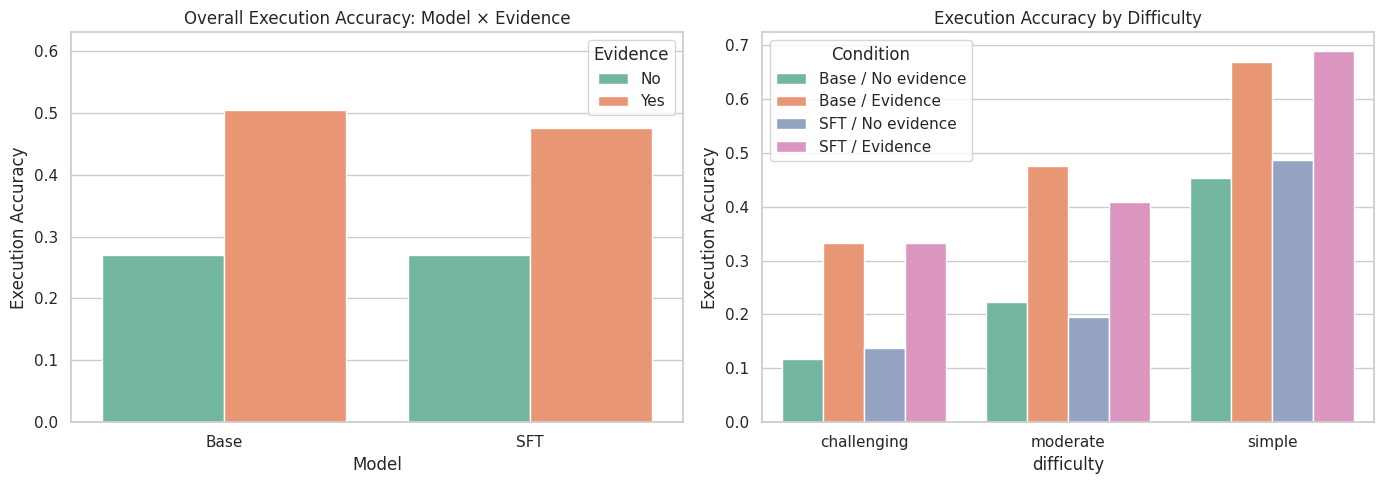

Saved chart: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_four_way/four_way_accuracy.png


In [22]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overall_plot = summary_table.rename(columns={"EX": "Execution Accuracy"})
sns.barplot(
    data=overall_plot, x="Model", y="Execution Accuracy", hue="Evidence",
    ax=axes[0], palette="Set2",
)
axes[0].set_ylim(0, max(0.1, overall_plot["Execution Accuracy"].max() * 1.25))
axes[0].set_title("Overall Execution Accuracy: Model × Evidence")

difficulty_long = difficulty_comparison.melt(
    id_vars=["difficulty", "count"],
    value_vars=[
        "base_no_evidence_ex", "base_with_evidence_ex",
        "sft_no_evidence_ex", "sft_with_evidence_ex",
    ],
    var_name="Condition",
    value_name="Execution Accuracy",
)
difficulty_long["Condition"] = difficulty_long["Condition"].map({
    "base_no_evidence_ex": "Base / No evidence",
    "base_with_evidence_ex": "Base / Evidence",
    "sft_no_evidence_ex": "SFT / No evidence",
    "sft_with_evidence_ex": "SFT / Evidence",
})
sns.barplot(
    data=difficulty_long,
    x="difficulty",
    y="Execution Accuracy",
    hue="Condition",
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("Execution Accuracy by Difficulty")

plt.tight_layout()
chart_path = PROJECT_DIR / "four_way_accuracy.png"
fig.savefig(chart_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved chart:", chart_path)


## 17. Inspect Improved and Regressed Examples for Every Paired Effect


In [23]:
def inspect_pair_changes(effect_name, max_rows=10):
    control_label, treatment_label = PAIR_SPECS[effect_name]
    change_column = f"change_{effect_name}"
    columns = [
        "position", "source_index", "db_id", "difficulty",
        "question", "evidence",
        f"predicted_sql_{control_label}",
        f"predicted_sql_{treatment_label}",
        "gold_sql", change_column,
    ]

    print(f"\n{effect_name}: improved examples")
    display(four_way.loc[four_way[change_column] == "improved", columns].head(max_rows))
    print(f"{effect_name}: regressed examples")
    display(four_way.loc[four_way[change_column] == "regressed", columns].head(max_rows))


for effect_name in PAIR_SPECS:
    inspect_pair_changes(effect_name, max_rows=10)



evidence_effect_base: improved examples


,position,source_index,db_id,difficulty,question,evidence,predicted_sql_baseline_no_evidence,predicted_sql_baseline_with_evidence,gold_sql,change_evidence_effect_base
0,0,0,debit_card_specializing,simple,What is the ratio of customers who pay in EUR against customers who pay in CZK?,ratio of customers who pay in EUR against customers who pay in CZK = count(Currency = 'EUR') / count(Currency = 'CZK').,SELECT SUM(CASE WHEN T2.Currency = 'EUR' THEN 1 ELSE 0 END) * 1.0 / SUM(CASE WHEN T2.Currency = 'CZK' THEN 1 ELSE 0 END) FROM transactions_1k AS T1 INNER JO...,SELECT CAST(SUM(CASE WHEN Currency = 'EUR' THEN 1 ELSE 0 END) AS REAL) / SUM(CASE WHEN Currency = 'CZK' THEN 1 ELSE 0 END) FROM customers,"SELECT CAST(SUM(IIF(Currency = 'EUR', 1, 0)) AS FLOAT) / SUM(IIF(Currency = 'CZK', 1, 0)) AS ratio FROM customers",improved
8,8,8,debit_card_specializing,simple,How much did customer 6 consume in total between August and November 2013?,Between August And November 2013 refers to Between 201308 And 201311; The first 4 strings of the Date values in the yearmonth table can represent year; The ...,SELECT SUM(Consumption) FROM yearmonth WHERE CustomerID = 6 AND Date BETWEEN '2013-08' AND '2013-11',SELECT SUM(Consumption) FROM yearmonth WHERE CustomerID = 6 AND Date BETWEEN '201308' AND '201311',SELECT SUM(Consumption) FROM yearmonth WHERE CustomerID = 6 AND Date BETWEEN '201308' AND '201311',improved
9,9,9,debit_card_specializing,simple,"How many more ""discount"" gas stations does the Czech Republic have compared to Slovakia?",Czech Republic can be represented as the Country value in gasstations table is 'CZE'; Slovakia can be represented as the Country value in the gasstations ta...,SELECT SUM(CASE WHEN Country = 'Czech Republic' THEN 1 ELSE 0 END) - SUM(CASE WHEN Country = 'Slovakia' THEN 1 ELSE 0 END) AS difference FROM gasstations WH...,SELECT SUM(CASE WHEN Country = 'CZE' THEN 1 ELSE 0 END) - SUM(CASE WHEN Country = 'SVK' THEN 1 ELSE 0 END) AS difference FROM gasstations WHERE Segment LIKE...,"SELECT SUM(IIF(Country = 'CZE', 1, 0)) - SUM(IIF(Country = 'SVK', 1, 0)) FROM gasstations WHERE Segment = 'Discount'",improved
12,12,12,debit_card_specializing,simple,"In February 2012, what percentage of customers consumed more than 528.3?",February 2012 refers to '201202' in yearmonth.date; The first 4 strings of the Date values in the yearmonth table can represent year; The 5th and 6th string...,SELECT CAST(SUM(CASE WHEN T2.Consumption > 528.3 THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(T1.CustomerID) FROM customers AS T1 INNER JOIN yearmonth AS T2 ON...,SELECT CAST(SUM(CASE WHEN T2.Consumption > 528.3 THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(T1.CustomerID) FROM customers AS T1 INNER JOIN yearmonth AS T2 ON...,"SELECT CAST(SUM(IIF(Consumption > 528.3, 1, 0)) AS FLOAT) * 100 / COUNT(CustomerID) FROM yearmonth WHERE Date = '201202'",improved
16,16,16,debit_card_specializing,simple,"Among the customers who paid in euro, how many of them have a monthly consumption of over 1000?",Pays in euro = Currency = 'EUR'.,SELECT COUNT(T2.CustomerID) FROM yearmonth AS T1 INNER JOIN customers AS T2 ON T1.CustomerID = T2.CustomerID WHERE T2.Currency = 'Euro' AND T1.Consumption >...,SELECT COUNT(T2.CustomerID) FROM yearmonth AS T1 INNER JOIN customers AS T2 ON T1.CustomerID = T2.CustomerID WHERE T2.Currency = 'EUR' AND T1.Consumption > ...,SELECT COUNT(*) FROM yearmonth AS T1 INNER JOIN customers AS T2 ON T1.CustomerID = T2.CustomerID WHERE T2.Currency = 'EUR' AND T1.Consumption > 1000.00,improved
17,17,17,debit_card_specializing,moderate,Please list the product descriptions of the transactions taken place in the gas stations in the Czech Republic.,Czech Republic can be represented as the Country value in the gasstations table is 'CZE';,SELECT T3.Description FROM transactions_1k AS T1 INNER JOIN gasstations AS T2 ON T1.GasStationID = T2.GasStationID INNER JOIN products AS T3 ON T1.ProductID...,SELECT DISTINCT T3.Description FROM transactions_1k AS T1 INNER JOIN gas

evidence_effect_base: regressed examples


,position,source_index,db_id,difficulty,question,evidence,predicted_sql_baseline_no_evidence,predicted_sql_baseline_with_evidence,gold_sql,change_evidence_effect_base
150,150,150,european_football_2,moderate,Please list the names of the players whose volley score and dribbling score are over 70.,volley score are over 70 refers to volleys > 70; dribbling score refers to dribbling are over 70 refers to dribbling > 70;,SELECT T1.player_name FROM Player AS T1 INNER JOIN Player_Attributes AS T2 ON T1.player_api_id = T2.player_api_id WHERE T2.volleys > 70 AND T2.dribbling > 70,SELECT T1.player_name FROM Player AS T1 INNER JOIN Player_Attributes AS T2 ON T1.player_api_id = T2.player_api_id WHERE T2.volvies > 70 AND T2.dribbling > 70,SELECT DISTINCT t1.player_name FROM Player AS t1 INNER JOIN Player_Attributes AS t2 ON t1.player_api_id = t2.player_api_id WHERE t2.volleys > 70 AND t2.drib...,regressed
202,202,202,formula_1,moderate,Name the driver with the most winning. Mention his nationality and what is his maximum point scores.,Full name of the driver refers to drivers.forename and drivers.surname; the most winning refers to MAX(COUNT(wins)); average point scores refers to MAX(poin...,"SELECT T1.forename, T1.surname, T1.nationality, MAX(T2.points) FROM drivers AS T1 INNER JOIN driverstandings AS T2 ON T1.driverid = T2.driverid WHERE T2.win...","SELECT T1.forename, T1.surname, T1.nationality, T2.points FROM drivers AS T1 INNER JOIN driverstandings AS T2 ON T1.driverid = T2.driverid GROUP BY T1.drive...","SELECT T1.forename, T1.surname, T1.nationality, MAX(T2.points) FROM drivers AS T1 INNER JOIN driverStandings AS T2 ON T2.driverId = T1.driverId WHERE T2.win...",regressed
218,218,218,formula_1,challenging,How much faster in percentage is the champion than the driver who finished the race last in the 2008 Australian Grand Prix?,"how much faster in percentage = divide(subtract(incremental time, champion time), last_driver time) * 100; last driver finished time = incremental time + ch...",SELECT ((MAX(T1.points) - MIN(T1.points)) / MAX(T1.points)) * 100 FROM results AS T1 INNER JOIN races AS T2 ON T1.raceid = T2.raceid WHERE T2.year = 2008 AN...,"SELECT \n ((strftime('%s', T1.time) - strftime('%s', T2.time)) / strftime('%s', T2.time)) * 100 AS percentage_faster\nFROM \n results AS T1\nJOIN \n ...","WITH time_in_seconds AS ( SELECT T1.positionOrder, CASE WHEN T1.positionOrder = 1 THEN (CAST(SUBSTR(T1.time, 1, 1) AS REAL) * 3600) + (CAST(SUBSTR(T1.time, ...",regressed
236,236,236,formula_1,challenging,List down top 3 German drivers who has the shortest average pit stop duration and were born between 1980-1985.,Full name of the driver refers to drivers.forename and drivers.surname; born between 1980-1985 refers to 1980<= year(dob) <=1985; Average pitstop duration r...,"SELECT T1.forename, T1.surname FROM drivers AS T1 INNER JOIN pitstops AS T2 ON T1.driverid = T2.driverid WHERE T1.nationality = 'German' AND T1.dob BETWEEN ...","SELECT T1.driverid, T1.forename, T1.surname FROM drivers AS T1 INNER JOIN pitstops AS T2 ON T1.driverid = T2.driverid WHERE STRFTIME('%Y', T1.dob) BETWEEN '...","SELECT T2.forename, T2.surname FROM pitStops AS T1 INNER JOIN drivers AS T2 on T1.driverId = T2.driverId WHERE T2.nationality = 'German' AND STRFTIME('%Y', ...",regressed
266,266,266,superhero,moderate,Provide the hair colour of the human superhero who is 185 cm tall.,185 cm tall refers to height_cm = 185; human superhero refers to race = 'human'; hair colour refers to colour where hair_colour_id = colour.id;,SELECT T2.colour FROM superhero AS T1 INNER JOIN colour AS T2 ON T1.hair_colour_id = T2.id WHERE T1.height_cm = 185 AND T1.race_id = ( SELECT id FROM race W...,SELECT T3.colour FROM superhero AS T1 INNER JOIN race AS T2 ON T1.race_id = T2.id INNER JOIN colour AS T3 ON T1.hair_colour_id = T3.id WHERE T1.height_cm = ...,SELECT DISTINCT T3.colour FROM superhero AS T1 INNER JOIN race AS T2 ON T1.race_id = T2.id INNER JOIN colour AS T3 ON T1.hair_colour_id 


evidence_effect_sft: improved examples


...

,position,source_index,db_id,difficulty,question,evidence,predicted_sql_baseline_no_evidence,predicted_sql_sft_no_evidence,gold_sql,change_sft_effect_no_evidence
22,22,22,debit_card_specializing,moderate,"For all the transactions happened during 8:00-9:00 in 2012/8/26, how many happened in CZE?",Czech Republic can be represented as the Country value in the gasstations table is 'CZE'; '2012/8/26' can be represented by '2012-08-26'; during 8:00-9:00 c...,SELECT COUNT(*) FROM transactions_1k AS T1 INNER JOIN gasstations AS T2 ON T1.GasStationID = T2.GasStationID WHERE T1.Date = '2012-08-26' AND T1.Time BETWEE...,SELECT COUNT(T1.GasStationID) FROM gasstations AS T1 INNER JOIN transactions_1k AS T2 ON T1.GasStationID = T2.GasStationID WHERE T2.Date = '2012-08-26' AND ...,SELECT COUNT(T1.TransactionID) FROM transactions_1k AS T1 INNER JOIN gasstations AS T2 ON T1.GasStationID = T2.GasStationID WHERE T1.Date = '2012-08-26' AND...,regressed
31,31,31,student_club,moderate,"Among the students from the Student_Club who attended the event ""Women's Soccer"", how many of them want a T-shirt that's in medium size?",Women's Soccer is an event name; T-shirt that is in medium size refers to t_shirt_size = 'Medium',SELECT COUNT(T1.member_id) FROM member AS T1 INNER JOIN attendance AS T2 ON T1.member_id = T2.link_to_member INNER JOIN event AS T3 ON T2.link_to_event = T3...,SELECT COUNT(T1.member_id) FROM attendance AS T1 INNER JOIN event AS T2 ON T1.link_to_event = T2.event_id INNER JOIN member AS T3 ON T1.link_to_member = T3....,SELECT COUNT(T1.event_id) FROM event AS T1 INNER JOIN attendance AS T2 ON T1.event_id = T2.link_to_event INNER JOIN member AS T3 ON T2.link_to_member = T3.m...,regressed
61,61,61,student_club,moderate,Name the event with the highest amount spent on advertisement.,Name of event refers to event_name; highest amount spent on advertisement refers to MAX(spent) where category = 'Advertisement',SELECT T1.event_name FROM event AS T1 INNER JOIN budget AS T2 ON T1.event_id = T2.link_to_event WHERE T2.category = 'Advertisement' ORDER BY T2.spent DESC L...,SELECT T1.event_name FROM event AS T1 INNER JOIN budget AS T2 ON T1.event_id = T2.link_to_event WHERE T2.category = 'advertisement' ORDER BY T2.spent DESC L...,SELECT T2.event_name FROM budget AS T1 INNER JOIN event AS T2 ON T1.link_to_event = T2.event_id WHERE T1.category = 'Advertisement' ORDER BY T1.spent DESC L...,regressed
66,66,66,student_club,moderate,Calculate the amount budgeted for 'April Speaker' event. List all the budgeted categories for said event in an ascending order based on their amount budgeted.,'April Speaker' is an event name; amount budgeted refers to SUM(amount); budget categories refers to category,"SELECT T1.category, T1.amount FROM budget AS T1 INNER JOIN event AS T2 ON T1.link_to_event = T2.event_id WHERE T2.event_name = 'April Speaker' ORDER BY T1.a...",SELECT T1.category FROM budget AS T1 INNER JOIN event AS T2 ON T1.link_to_event = T2.event_id WHERE T2.event_name = 'April Speaker' ORDER BY T1.amount ASC,"SELECT T2.category, SUM(T2.amount) FROM event AS T1 JOIN budget AS T2 ON T1.event_id = T2.link_to_event WHERE T1.event_name = 'April Speaker' GROUP BY T2.ca...",regressed
67,67,67,student_club,simple,Mention the total expense used on 8/20/2019.,total expense refers SUM(cost) where expense_date = '2019-08-20',SELECT SUM(cost) FROM expense WHERE expense_date = '2019-08-20',SELECT SUM(cost) FROM expense WHERE expense_date = '2019-08-20' AND approved = 'yes';,SELECT SUM(cost) FROM expense WHERE expense_date = '2019-08-20',regressed
81,81,81,thrombosis_prediction,simple,What is the disease patient '30609' diagnosed with. List all the date of laboratory tests done for this patient.,'30609' is the Patient ID; disease means Diagnosis,"SELECT DISTINCT T1.Diagnosis, T2.Date FROM Patient AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID WHERE T1.ID = 30609","SELECT DISTINCT T1.Description, T2.Date FROM Patient AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.I


sft_effect_with_evidence: improved examples


,position,source_index,db_id,difficulty,question,evidence,predicted_sql_baseline_with_evidence,predicted_sql_sft_with_evidence,gold_sql,change_sft_effect_with_evidence
3,3,3,debit_card_specializing,challenging,What was the difference in gas consumption between CZK-paying customers and EUR-paying customers in 2012?,Year 2012 can be presented as Between 201201 And 201212; The first 4 strings of the Date values in the yearmonth table can represent year; Difference in Con...,SELECT SUM(CASE WHEN T1.Currency = 'CZK' THEN T2.Consumption ELSE 0 END) - SUM(CASE WHEN T1.Currency = 'EUR' THEN T2.Consumption ELSE 0 END) AS diff FROM cu...,SELECT SUM(CASE WHEN T1.Currency = 'CZK' THEN T2.Consumption ELSE 0 END) - SUM(CASE WHEN T1.Currency = 'EUR' THEN T2.Consumption ELSE 0 END) FROM customers ...,"SELECT SUM(IIF(T1.Currency = 'CZK', T2.Consumption, 0)) - SUM(IIF(T1.Currency = 'EUR', T2.Consumption, 0)) FROM customers AS T1 INNER JOIN yearmonth AS T2 O...",improved
116,116,116,thrombosis_prediction,simple,How many patients with an Ig G higher than normal?,Ig G higher than normal refers to IGG >= 2000; Should consider DISTINCT in the final result;,SELECT COUNT(DISTINCT ID) FROM Laboratory WHERE IGG >= 2000,SELECT COUNT(DISTINCT T1.ID) FROM Laboratory AS T1 INNER JOIN Examination AS T2 ON T1.ID = T2.ID WHERE T1.IGG > 2000,SELECT COUNT(DISTINCT T1.ID) FROM Patient AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID INNER JOIN Examination AS T3 ON T3.ID = T2.ID WHERE T2.IGG >= 2000,improved
117,117,117,thrombosis_prediction,moderate,"Among the patients with a normal Ig G level, how many of them have symptoms?",normal Ig G level refers to IGG > 900 and IGG < 2000; have symptoms refers to Symptoms IS NOT NULL;,SELECT COUNT(DISTINCT T1.ID) FROM Examination AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID WHERE T2.IGG BETWEEN 900 AND 2000 AND T1.Symptoms IS NOT NULL,SELECT COUNT(T1.ID) FROM Examination AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID WHERE T1.Symptoms IS NOT NULL AND T2.IGG BETWEEN 900 AND 2000,SELECT COUNT(T1.ID) FROM Patient AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID INNER JOIN Examination AS T3 ON T3.ID = T2.ID WHERE T2.IGG BETWEEN 900 A...,improved
119,119,119,thrombosis_prediction,moderate,"For the patients with an abnormal Ig M level, what is the most common disease they are diagnosed with?",abnormal Ig M level refers to IGM <=40 OR IGM >= 400; most common disease refers to MAX(COUNT(Diagnosis));,SELECT T2.Diagnosis FROM Laboratory AS T1 INNER JOIN Examination AS T2 ON T1.ID = T2.ID WHERE T1.IGM <= 40 OR T1.IGM >= 400 GROUP BY T2.Diagnosis ORDER BY C...,SELECT T2.Diagnosis FROM Laboratory AS T1 INNER JOIN Patient AS T2 ON T1.ID = T2.ID WHERE T1.IGM < 40 OR T1.IGM > 400 GROUP BY T2.Diagnosis ORDER BY COUNT(T...,SELECT T1.Diagnosis FROM Patient AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID WHERE T2.IGM NOT BETWEEN 40 AND 400 GROUP BY T1.Diagnosis ORDER BY COUNT...,improved
127,127,127,thrombosis_prediction,challenging,"For the patients with a normal range of creatinine phosphokinase, how many of them have a positive measure of degree of coagulation?",normal range of creatinine phosphokinase refers to CPK < 250; positive measure of degree of coagulation refers to KCT = '+' or RVVT = '+' or LAC = '+' ;,SELECT COUNT(DISTINCT T1.ID) FROM Examination AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID WHERE T2.CPK < 250 AND (T1.KCT = '+' OR T1.RVVT = '+' OR T1...,SELECT COUNT(T1.ID) FROM Examination AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID WHERE T2.CPK < 250 AND (T1.KCT = '+' OR T1.RVVT = '+' OR T1.LAC = '+'),SELECT COUNT(T1.ID) FROM Patient AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID INNER JOIN Examination AS T3 ON T1.ID = T3.ID WHERE T2.CPK < 250 AND (T3...,improved
144,144,144,european_football_2,moderate,"From 2010 to 2015, what was the average overall rating of players who are higher than 170?","from 2010 to 2015 refers to strftime('%Y', date) >= '2010' AND <= '2015'; average overall rating = SU

sft_effect_with_evidence: regressed examples


,position,source_index,db_id,difficulty,question,evidence,predicted_sql_baseline_with_evidence,predicted_sql_sft_with_evidence,gold_sql,change_sft_effect_with_evidence
0,0,0,debit_card_specializing,simple,What is the ratio of customers who pay in EUR against customers who pay in CZK?,ratio of customers who pay in EUR against customers who pay in CZK = count(Currency = 'EUR') / count(Currency = 'CZK').,SELECT CAST(SUM(CASE WHEN Currency = 'EUR' THEN 1 ELSE 0 END) AS REAL) / SUM(CASE WHEN Currency = 'CZK' THEN 1 ELSE 0 END) FROM customers,"SELECT CAST(SUM(IIF(T2.Currency = 'EUR', 1, 0)) AS REAL) * 100 / SUM(IIF(T2.Currency = 'CZK', 1, 0)) FROM transactions_1k AS T1 INNER JOIN customers AS T2 O...","SELECT CAST(SUM(IIF(Currency = 'EUR', 1, 0)) AS FLOAT) / SUM(IIF(Currency = 'CZK', 1, 0)) AS ratio FROM customers",regressed
9,9,9,debit_card_specializing,simple,"How many more ""discount"" gas stations does the Czech Republic have compared to Slovakia?",Czech Republic can be represented as the Country value in gasstations table is 'CZE'; Slovakia can be represented as the Country value in the gasstations ta...,SELECT SUM(CASE WHEN Country = 'CZE' THEN 1 ELSE 0 END) - SUM(CASE WHEN Country = 'SVK' THEN 1 ELSE 0 END) AS difference FROM gasstations WHERE Segment LIKE...,SELECT SUM(CASE WHEN T2.Country = 'CZE' THEN 1 ELSE 0 END) - SUM(CASE WHEN T2.Country = 'SVK' THEN 1 ELSE 0 END) FROM transactions_1k AS T1 INNER JOIN gasst...,"SELECT SUM(IIF(Country = 'CZE', 1, 0)) - SUM(IIF(Country = 'SVK', 1, 0)) FROM gasstations WHERE Segment = 'Discount'",regressed
31,31,31,student_club,moderate,"Among the students from the Student_Club who attended the event ""Women's Soccer"", how many of them want a T-shirt that's in medium size?",Women's Soccer is an event name; T-shirt that is in medium size refers to t_shirt_size = 'Medium',SELECT COUNT(T1.member_id) FROM member AS T1 INNER JOIN attendance AS T2 ON T1.member_id = T2.link_to_member INNER JOIN event AS T3 ON T2.link_to_event = T3...,SELECT COUNT(T1.member_id) FROM attendance AS T1 INNER JOIN event AS T2 ON T1.link_to_event = T2.event_id WHERE T2.event_name = 'Women''s Soccer' AND T1.lin...,SELECT COUNT(T1.event_id) FROM event AS T1 INNER JOIN attendance AS T2 ON T1.event_id = T2.link_to_event INNER JOIN member AS T3 ON T2.link_to_member = T3.m...,regressed
80,80,80,thrombosis_prediction,moderate,What is the ratio of outpatient to inpatient followed up treatment among all the 'SLE' diagnosed patient?,'SLE' diagnosed patient means Diagnosis = 'SLE'; inpatient refers to Admission = '+'; outpatient refers to Admission = '-'; calculation = DIVIDE(COUNT(ID) ...,SELECT CAST(SUM(CASE WHEN Admission = '+' THEN 1 ELSE 0 END) AS REAL) / SUM(CASE WHEN Admission = '-' THEN 1 ELSE 0 END) FROM Patient WHERE Diagnosis = 'SLE',"SELECT CAST(SUM(IIF(T1.Admission = '-', 1, 0)) AS REAL) / SUM(IIF(T1.Admission = '+', 1, 0)) FROM Patient AS T1 INNER JOIN Examination AS T2 ON T1.ID = T2.I...",SELECT SUM(CASE WHEN Admission = '+' THEN 1.0 ELSE 0 END) / SUM(CASE WHEN Admission = '-' THEN 1 ELSE 0 END) FROM Patient WHERE Diagnosis = 'SLE',regressed
89,89,89,thrombosis_prediction,challenging,What is the ratio of male to female patients among all those with abnormal uric acid counts?,"male refers to SEX = 'M'; female refers to SEX = 'F'; abnormal uric acid refers to UA < = '8.0' where SEX = 'M', UA < = '6.5' where SEX = 'F'; calculation =...",SELECT CAST(SUM(CASE WHEN T1.SEX = 'M' THEN 1 ELSE 0 END) AS REAL) / SUM(CASE WHEN T1.SEX = 'F' THEN 1 ELSE 0 END) FROM Patient AS T1 INNER JOIN Laboratory ...,SELECT CAST(SUM(CASE WHEN T1.SEX = 'M' THEN 1 ELSE 0 END) AS REAL) / SUM(CASE WHEN T1.SEX = 'F' THEN 1 ELSE 0 END) FROM Patient AS T1 INNER JOIN Laboratory ...,SELECT CAST(SUM(CASE WHEN T2.UA <= 8.0 AND T1.SEX = 'M' THEN 1 ELSE 0 END) AS REAL) / SUM(CASE WHEN T2.UA <= 6.5 AND T1.SEX = 'F' THEN 1 ELSE 0 END) FROM Pa...,regressed
93,93,93,thrombosis_prediction,challenging,"For the patient who was born on 1959/2/18, what is the de

## 18. Write the Final Comparison Summary and List All Result Files


In [24]:
comparison_summary = {
    "dataset": {
        "id": HF_DATASET_ID,
        "revision": HF_REVISION,
        "split": HF_SPLIT,
        "size": int(len(four_way)),
        "unique_databases": int(four_way["db_id"].nunique()),
        "sha256": DATASET_SHA256,
    },
    "experiments": SUMMARIES_BY_EXPERIMENT,
    "paired_effects": paired_effects.to_dict(orient="records"),
    "interaction": interaction_summary.iloc[0].to_dict(),
    "interpretation": {
        "primary_metric": "execution_accuracy",
        "paired_delta_definition": "treatment_execution_accuracy - control_execution_accuracy",
        "interaction_definition": "(SFT evidence effect) - (Base evidence effect)",
        "mcnemar_test": "exact two-sided binomial test on discordant paired outcomes",
        "bootstrap_ci": "paired 10000-sample percentile bootstrap of EX delta",
    },
}
atomic_write_json(comparison_summary, PROJECT_DIR / "four_way_comparison_summary.json")

result_files = sorted(
    p for p in PROJECT_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in {".csv", ".json", ".jsonl", ".png"}
)

print("Evaluation complete. Result files:")
for path in result_files:
    print(f" - {path.name} ({path.stat().st_size / 1024:.1f} KB)")

print("\nMost important files:")
print(" - four_way_comparison_summary.json: final machine-readable conclusions")
print(" - four_way_metric_summary.csv: EX and efficiency metrics for all four conditions")
print(" - paired_effects.csv: the four controlled paired comparisons")
print(" - interaction_summary.csv: difference-in-differences estimate")
print(" - four_way_per_example.csv: all predictions aligned by example")
print(" - four_way_by_difficulty.csv / four_way_by_database.csv: breakdowns")
print(" - *_minidev500_results.csv: complete per-example output for each condition")


Evaluation complete. Result files:
 - baseline_no_evidence_minidev500_results.csv (488.2 KB)
 - baseline_no_evidence_official_predictions.json (107.5 KB)
 - baseline_no_evidence_run_config.json (1.1 KB)
 - baseline_no_evidence_summary.json (2.7 KB)
 - baseline_with_evidence_minidev500_results.csv (552.3 KB)
 - baseline_with_evidence_official_predictions.json (109.1 KB)
 - baseline_with_evidence_run_config.json (1.1 KB)
 - baseline_with_evidence_summary.json (2.7 KB)
 - four_way_accuracy.png (101.7 KB)
 - four_way_by_database.csv (1.9 KB)
 - four_way_by_difficulty.csv (0.7 KB)
 - four_way_comparison_summary.json (15.5 KB)
 - four_way_metric_summary.csv (0.4 KB)
 - four_way_per_example.csv (705.2 KB)
 - interaction_summary.csv (0.1 KB)
 - paired_effects.csv (0.7 KB)
 - sft_no_evidence_minidev500_results.csv (488.8 KB)
 - sft_no_evidence_official_predictions.json (110.6 KB)
 - sft_no_evidence_run_config.json (1.5 KB)
 - sft_no_evidence_summary.json (2.7 KB)
 - sft_with_evidence_minidev500

## Guide to Interpreting the Results

Review the results in this order:

1. `execution_accuracy`: the primary metric, indicating whether the generated SQL produces the same result as the Gold SQL.
2. `evidence_effect_base`: Base+Evidence EX minus Base-No-Evidence EX. This isolates what evidence contributes before fine-tuning.
3. `evidence_effect_sft`: SFT+Evidence EX minus SFT-No-Evidence EX. This shows whether the fine-tuned model can use evidence.
4. `sft_effect_no_evidence` and `sft_effect_with_evidence`: the SFT gain at a fixed prompt-information condition. These are the fair SFT-vs-Base comparisons.
5. `interaction_delta`: whether SFT changes the marginal usefulness of evidence. A positive value means evidence helps SFT more than it helps Base.
6. `improved`, `regressed`, and `net_improvement`: paired example-level changes that overall accuracy can hide.
7. Paired bootstrap 95% CI and McNemar exact p-value: use these to judge whether a paired delta is stable rather than treating runs as independent samples.
8. Breakdowns by difficulty and database: verify whether effects are concentrated in specific subsets.
9. `Normalized Exact Match` compares normalized SQL text only; it does not indicate execution equivalence and should be treated as a diagnostic metric.

Finally, Mini-Dev remains a public development set. As long as you do not use these 500 examples to select checkpoints, revise the prompt, or tune hyperparameters, it can serve as a credible independent evaluation set at this stage. Once you adjust the model based on these results, it becomes your new validation set.
